In [4]:
def plot_fiber_only_map(ref_lat, ref_lon, das_hyb, earthquake_location,
                        corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
                        lat_range, lon_range, fiber_file,
                        title="Fiber Coherence Map", event_name=None, ax=None,
                        boundary_margin=5):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.interpolate import griddata
    import numpy as np
    import os

    # --- Helper: Cartesian -> Geographic ---
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    file_dir = os.path.dirname(fiber_file)

    # --- Mask boundaries to avoid edge peaks ---
    corrmatrix_das = corrmatrix_das[
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin,
        boundary_margin:-boundary_margin
    ]
    cartesian_grid_x = cartesian_grid_x[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]
    cartesian_grid_y = cartesian_grid_y[boundary_margin:-boundary_margin, boundary_margin:-boundary_margin]

    # --- Normalize the coherence matrix ---
    corrmatrix = corrmatrix_das / np.nanmax(corrmatrix_das)
    nx, ny, nz = np.shape(corrmatrix)
    CXY = np.max(corrmatrix, axis=2).T

    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

    interpolated_CXY = griddata(
        (lat_grid.flatten(), lon_grid.flatten()), 
        CXY.flatten(), 
        (grid_lat, grid_lon), 
        method='cubic'
    )

    # --- Setup figure/axis ---
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
        created_fig = True
    else:
        fig = ax.get_figure()

    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=20, cmap='viridis', alpha=0.8)

    # --- Event & Max Coherence ---
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Catalog Location')

    max_index = np.unravel_index(np.nanargmax(interpolated_CXY), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    print(f"Max Coherence Location, lat, lon: {max_lat}, {max_lon}")
    ax.scatter(max_lon, max_lat, marker='*', facecolors='none', edgecolors='black', s=130, label='Max Coherence')

    # --- DAS HYB points ---
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if created_fig:
        cbar = fig.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.5, aspect=20)
        cbar.set_label('Normalized Coherence')

    # --- Legend ---
    custom_handles = [
        Line2D([0], [0], marker='*', color='red', label='Cluster center', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='*', color='none', label='Max Coherence', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='crimson', label='DAS fiber', linestyle='', markersize=6)
    ]
    ax.legend(handles=custom_handles, loc='lower right', fontsize='small', frameon=True)

    if created_fig:
        output_file = os.path.join(file_dir, f"{event_name}_fiber_map.pdf" if event_name else "fiber_map.pdf")
        plt.savefig(output_file, bbox_inches='tight')
        plt.show()



--- Processing Event 'cluster' for 'Orion' ---
Max Coherence Location, lat, lon: 38.410939510939514, 20.47165001913133

--- Processing Event 'cluster' for 'Random' ---
Max Coherence Location, lat, lon: 38.40122265122265, 20.465476155060166

--- Processing Event 'cluster' for 'Hybrid_gilbert' ---
Max Coherence Location, lat, lon: 38.410939510939514, 20.465476155060166

--- Processing Event 'cluster' for 'Stations' ---
Max Coherence Location, lat, lon: 38.39636422136422, 20.483997747273666


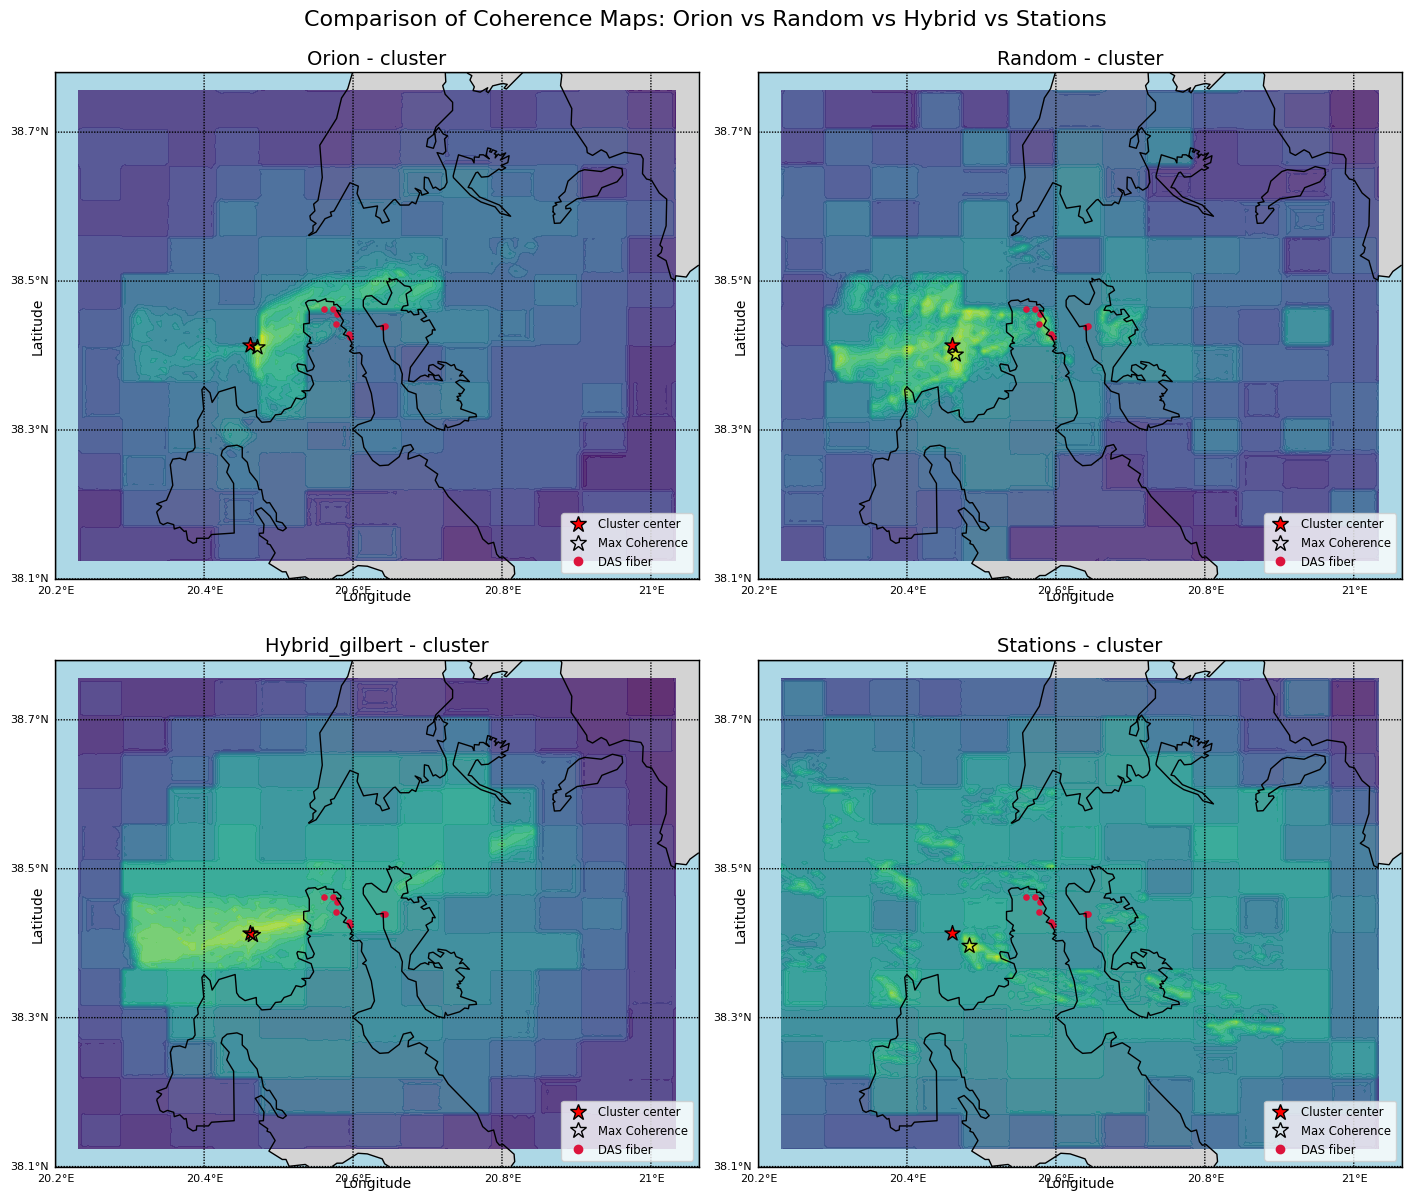

In [29]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
ref_lat = 38.10
ref_lon = 20.20

# --- DAS Hybrid Geometry ---
das_hyb = {
    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
}

# --- Grid Parameters ---
nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
events = {
    'cluster': (38.4140, 20.461, 14.5),
}

# --- Data Roots ---
base_dirs = {
    "Orion": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0311/fiber_orion", "fiber_orion.loc", "fiber"),
    "Random": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0311/fiber_uniform","fiber_uniform.loc", "fiber"),
    "Hybrid_gilbert": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0311/hybrid_gilbert","hybrid_gilbert.loc", "hybrid"),      # <-- Add path to Hybrid results
    "Stations": ("/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/kef0311/stations", "stations.loc", "stations"),  # <-- Add path to Stations results
}


def select_highest_coherence_file(folder, loc_filename, npy_suffix):
    loc_file = os.path.join(folder, loc_filename)
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"corrmatrix_trial_{max_idx}_{npy_suffix}.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

for ax, (label, (base_dir, loc_file, npy_suffix)) in zip(axes, base_dirs.items()):
    try:
        fiber_file = select_highest_coherence_file(base_dir, loc_file, npy_suffix)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )


fig.suptitle("Comparison of Coherence Maps: Orion vs Random vs Hybrid vs Stations", fontsize=16)
plt.show()

Error loading coherence file for Orion: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion/fiber/fiber.loc
Error loading coherence file for Random: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_random/fiber/fiber.loc
Error loading coherence file for Non-Selected: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/_non_selected/fiber/fiber.loc


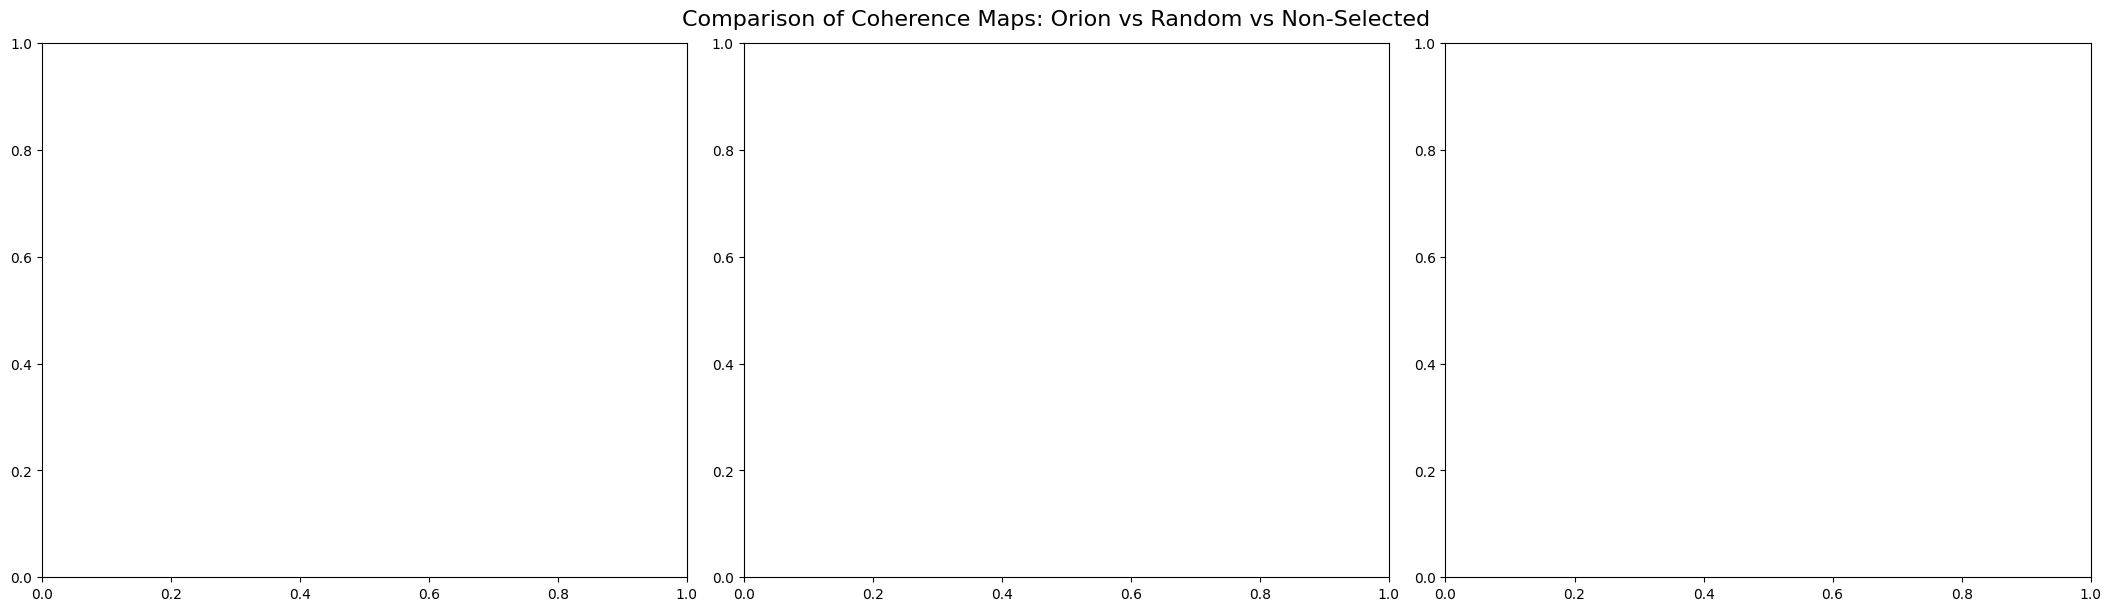

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
ref_lat = 38.10
ref_lon = 20.20

# --- DAS Hybrid Geometry ---
das_hyb = {
    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
}

# --- Grid Parameters ---
nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
events = {
    'cluster': (38.3755, 20.4237, 14.5),
}

# --- Event List ---
#events = {
#    'catalog': (38.4075, 20.4237, 14.5),
#}



# --- Event List ---
#events = {
#    'catalog': (38.4124,20.4601, 14.5),
#}

#events = {
#    'catalog': (38.399,20.4735,14.5),
#}


# --- Data Roots ---
base_dirs = {
    "Orion": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_orion",
    "Random": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/fiber_random",
    "Non-Selected": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0140/_non_selected"
}


def select_highest_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{max_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- Loop over each data version ---
for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()


Error loading coherence file for Orion: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion/fiber/fiber.loc
Error loading coherence file for Random: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_random/fiber/fiber.loc
Error loading coherence file for Non-Selected: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/_non_selected/fiber/fiber.loc
Error loading non-selected coherence file: Missing .loc file: /home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion/fiber/fiber.loc


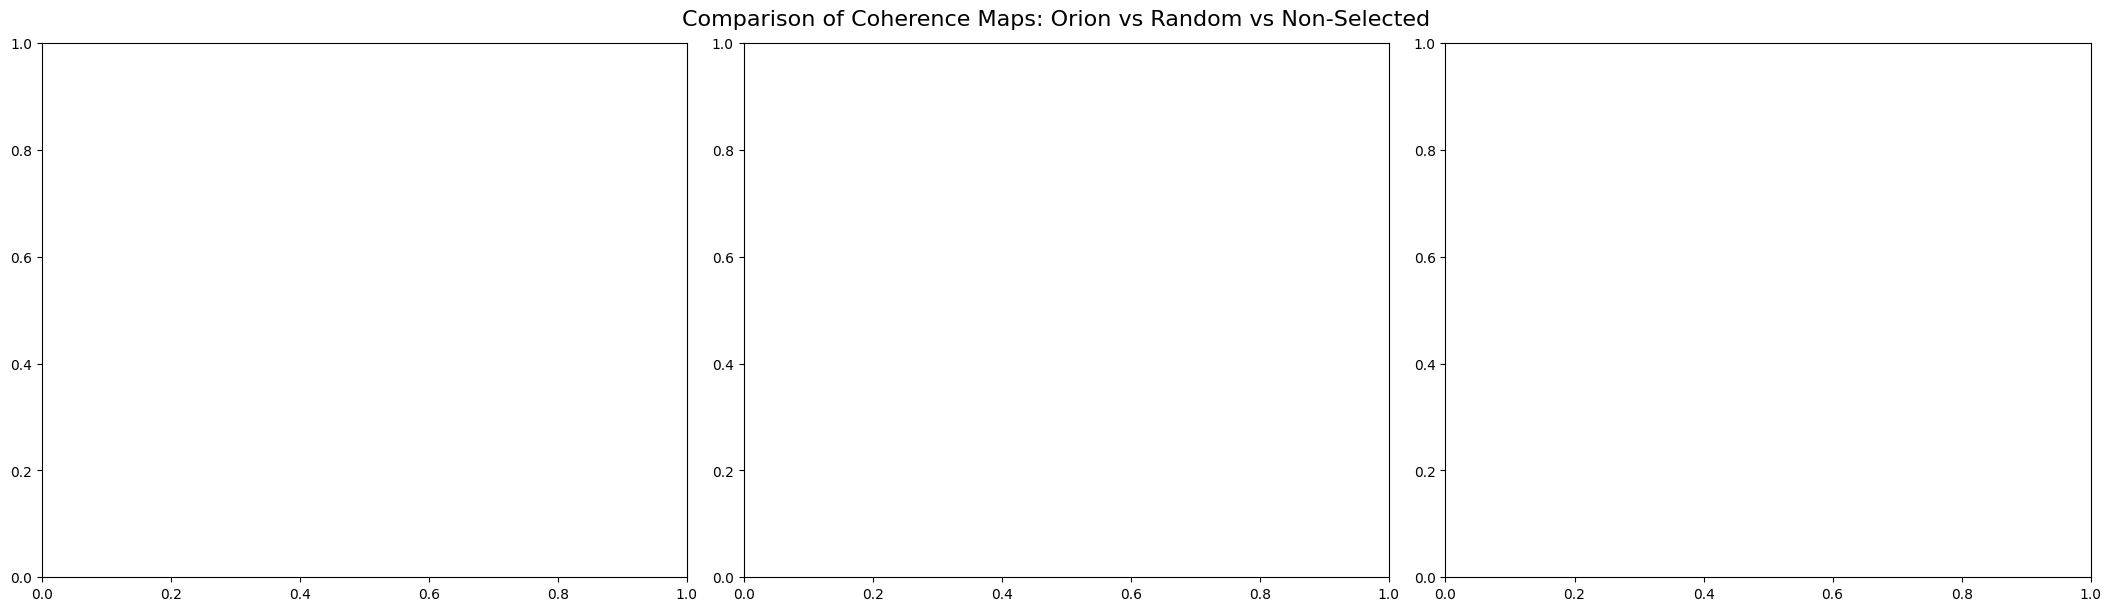

In [4]:
# --- Additional function to select non-maximal coherence file ---
def select_non_max_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    if len(coherence) < 2:
        raise ValueError("Not enough coherence entries to select a non-maximal value.")

    sorted_indices = np.argsort(coherence)[::-1]  # Descending order
    second_idx = sorted_indices[1]

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{second_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file

# --- Plotting Comparison with Third Panel ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

# --- Third subplot for non-selected trial (from Orion, for example) ---
try:
    fiber_file_non_selected = select_non_max_coherence_file(base_dirs["Orion"])
    corrmatrix_das_non_selected = np.load(fiber_file_non_selected).reshape((nx, ny, nz))
    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for 'Orion - Non-Selected' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das_non_selected, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file_non_selected,
            title=f"Orion - Non-Selected - {name}", event_name=name,
            ax=axes[2]
        )
except Exception as e:
    print(f"Error loading non-selected coherence file: {e}")

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()


In [11]:
def plot_fiber_only_map_with_maxima_no_cat(
    ref_lat, ref_lon, das_hyb,
    earthquake_location, cartesian_grid_x,
    cartesian_grid_y, lat_range, lon_range,
    parent_folder,
    title="Fiber Maxima Map",
    magnitude_threshold=0.0
):
    import os, glob, re
    from collections import defaultdict
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from math import radians, sin, cos, sqrt, atan2
    from numpy import median

    # --- Parameters ---
    depth_scale = 0.5  # km per depth index (adjust if different)
    cmap = plt.cm.binary

    # --- Helpers ---
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        R = 6371.0  # km
        lat = origin_lat + (y / R) * (180.0 / np.pi)
        lon = origin_lon + (x / (R * np.cos(np.radians(origin_lat)))) * (180.0 / np.pi)
        return lat, lon

    def distance_3d(lat1, lon1, depth1, lat2, lon2, depth2):
        """3D Euclidean distance (km) between two geocentric points using lat/lon/depth."""
        R = 6371.0
        lat1_r, lon1_r, lat2_r, lon2_r = map(radians, [lat1, lon1, lat2, lon2])
        x1 = (R - depth1) * cos(lat1_r) * cos(lon1_r)
        y1 = (R - depth1) * cos(lat1_r) * sin(lon1_r)
        z1 = (R - depth1) * sin(lat1_r)
        x2 = (R - depth2) * cos(lat2_r) * cos(lon2_r)
        y2 = (R - depth2) * cos(lat2_r) * sin(lon2_r)
        z2 = (R - depth2) * sin(lat2_r)
        return sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name):
        """
        Returns list of tuples:
          (lat_max, lon_max, depth_cxz_km, depth_cyz_km)
        where depth_* are computed from CXZ and CYZ maxima (converted with depth_scale).
        """
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        results = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return results

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))
        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                # normalize safely
                max_val = np.nanmax(corrmatrix)
                if max_val == 0 or np.isnan(max_val):
                    continue
                corrmatrix = corrmatrix / max_val

                # --- XY coarse + refine ---
                CXY = np.max(corrmatrix, axis=2).T  # shape (ny, nx)
                coarse_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                ws = 10
                i_min = max(coarse_idx[0] - ws, 0)
                i_max = min(coarse_idx[0] + ws + 1, CXY.shape[0])
                j_min = max(coarse_idx[1] - ws, 0)
                j_max = min(coarse_idx[1] + ws + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zf = 10
                CXY_fine = zoom(CXY_local, zf, order=3)
                x_fine = zoom(x_local, zf, order=1)
                y_fine = zoom(y_local, zf, order=1)

                fine_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_idx]
                y_max = y_fine[fine_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                # --- Depth from CXZ and CYZ maxima ---
                # CXZ: max along Y => shape (nx, nz)
                CXZ = np.max(corrmatrix, axis=1)
                # CYZ: max along X => shape (ny, nz)
                CYZ = np.max(corrmatrix, axis=0)

                # locate depth index of maxima
                idx_cxz = np.nanargmax(CXZ)
                # np.unravel_index to get (ix, iz)
                ix_cxz, iz_cxz = np.unravel_index(idx_cxz, CXZ.shape)
                iy_cyz, iz_cyz = np.unravel_index(np.nanargmax(CYZ), CYZ.shape)

                depth_cxz_km = iz_cxz * depth_scale
                depth_cyz_km = iz_cyz * depth_scale

                results.append((lat_max, lon_max, depth_cxz_km, depth_cyz_km))

            except Exception as e:
                # skip problematic files but keep processing
                print(f"Skipping file {file}: {e}")
                continue

        return results

    def plot_50pct_contour(ax, coords, color, label):
        """Plot 50% KDE contour and return a legend proxy Line2D or None."""
        if len(coords) < 5:
            return None
        arr = np.array(coords).T  # shape (2, N) with [lon, lat]
        try:
            kde = gaussian_kde(arr)
        except Exception:
            return None
        x_min, x_max = arr[0].min(), arr[0].max()
        y_min, y_max = arr[1].min(), arr[1].max()

        # small padding
        dx = (x_max - x_min) * 0.1 if x_max > x_min else 0.01
        dy = (y_max - y_min) * 0.1 if y_max > y_min else 0.01
        xgrid, ygrid = np.mgrid[x_min - dx:x_max + dx:300j, y_min - dy:y_max + dy:300j]
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        # find contour level for 50% probability mass
        vals_sorted = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(vals_sorted)
        cumsum /= cumsum[-1]
        idx = np.searchsorted(cumsum, 0.5)
        if idx >= len(vals_sorted):
            level = vals_sorted[-1]
        else:
            level = vals_sorted[idx]

        cs = ax.contour(xgrid, ygrid, kde_vals, levels=[level], colors=[color],
                        linestyles='dashed', linewidths=4, alpha=0.8)
        return Line2D([0], [0], color=color, lw=2, label=label)

    # --- Read catalog ---
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))
    lat_dict = dict(zip(catalog_df['evid'], catalog_df['latitude']))
    lon_dict = dict(zip(catalog_df['evid'], catalog_df['longitude']))
    depth_dict = dict(zip(catalog_df['evid'], catalog_df['depth']))

    # --- event folders ---
    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=5, scale_factor=25):
        return base_size + scale_factor * mag

    # --- Collect detections and distances ---
    orion_points = []    # list of dicts: {lon, lat, depth, size, event_id}
    uniform_points = []
    per_event_orion_depths = defaultdict(list)
    per_event_uniform_depths = defaultdict(list)
    orion_distances = []
    uniform_distances = []
    orion_coords = []
    uniform_coords = []
    catalog_coords = []
    shown_event_ids = set()

    for event_id in event_ids:
        mag = magnitude_dict.get(event_id, None)
        if mag is None or mag < magnitude_threshold:
            continue
        shown_event_ids.add(event_id)

        cat_lat = lat_dict.get(event_id, None)
        cat_lon = lon_dict.get(event_id, None)
        cat_depth = depth_dict.get(event_id, None)
        # skip if catalog lacks geometry (we still might want to contour later, but distances require coords)
        if cat_lat is None or cat_lon is None or cat_depth is None:
            # still try to collect detections for contours
            cat_valid = False
        else:
            cat_valid = True
            catalog_coords.append((cat_lon, cat_lat))

        ms = marker_size_from_magnitude(mag)

        # UNIFORM detections
        uniform_locs = collect_refined_max_locations_for_variant(parent_folder, event_id, 'fiber_uniform')
        for lat, lon, depth_cxz_km, depth_cyz_km in uniform_locs:
            depth_est = 0.5 * (depth_cxz_km + depth_cyz_km)
            uniform_points.append({'lon': lon, 'lat': lat, 'depth': depth_est, 'size': ms, 'event_id': event_id})
            uniform_coords.append((lon, lat))
            per_event_uniform_depths[event_id].append(depth_est)
            if cat_valid:
                uniform_distances.append(distance_3d(cat_lat, cat_lon, cat_depth, lat, lon, depth_est))

        # ORION detections
        orion_locs = collect_refined_max_locations_for_variant(parent_folder, event_id, 'fiber_orion')
        for lat, lon, depth_cxz_km, depth_cyz_km in orion_locs:
            depth_est = 0.5 * (depth_cxz_km + depth_cyz_km)
            orion_points.append({'lon': lon, 'lat': lat, 'depth': depth_est, 'size': ms, 'event_id': event_id})
            orion_coords.append((lon, lat))
            per_event_orion_depths[event_id].append(depth_est)
            if cat_valid:
                orion_distances.append(distance_3d(cat_lat, cat_lon, cat_depth, lat, lon, depth_est))



    # --- Prepare figure with map, histogram, scatter (depth comparison) ---
    fig, (ax_map, ax_hist, ax_scatter) = plt.subplots(3, 1, figsize=(8, 14),
                                                     gridspec_kw={'height_ratios': [2.5, 1, 1]},
                                                     dpi=300)
    # --- Map base ---
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax_map)
    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='whitesmoke')
    m.drawmapboundary(fill_color='whitesmoke')
    # optional grid
    try:
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=8)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=8)
    except Exception:
        pass

    # --- Single depth color scale (based on all detected depths) ---
    all_depths = [p['depth'] for p in orion_points] + [p['depth'] for p in uniform_points]

    norm = Normalize(vmin=0, vmax=10)


    if uniform_points:
        xs = [p['lon'] for p in uniform_points]
        ys = [p['lat'] for p in uniform_points]
        depths = [p['depth'] for p in uniform_points]
        sizes = [p['size'] for p in uniform_points]
        sc_uniform = ax_map.scatter(xs, ys, c=depths, cmap=cmap, norm=norm,
                                    s=sizes, marker='o', edgecolors='k', linewidths=0.4,
                                    alpha=0.5, label='Uniform')
    else:
        sc_uniform = None


    # --- Plot ORION and UNIFORM as two different markers but same colormap (depth-coded) ---
    if orion_points:
        xs = [p['lon'] for p in orion_points]
        ys = [p['lat'] for p in orion_points]
        depths = [p['depth'] for p in orion_points]
        sizes = [p['size'] for p in orion_points]
        sc_orion = ax_map.scatter(xs, ys, c=depths, cmap=cmap, norm=norm,
                                  s=sizes, marker='*', edgecolors='k', linewidths=0.4,
                                  alpha=0.5, label='ORION')
    else:
        sc_orion = None

    # --- DAS fiber overlay (if available) ---
    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    try:
        if os.path.isdir(das_csv_path):
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv"):
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        ax_map.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                       color='darkorange', linewidths=0.6, edgecolor='k', s=25, alpha=0.9,
                                       label="DAS fiber")
                    break
    except Exception as e:
        print(f"Error loading DAS CSV: {e}")

    # --- Single colorbar for depth ---
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # for colorbar
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.035, pad=0.02)
    cbar.set_label("Estimated depth (km)")

    ax_map.set_title(title, fontsize=14)

    # --- 50% KDE contours (ORION, UNIFORM, catalog) ---
    legend_proxies = []
    proxy = plot_50pct_contour(ax_map, orion_coords, 'darkred', 'ORION 50% contour')
    if proxy:
        legend_proxies.append(proxy)
    proxy = plot_50pct_contour(ax_map, uniform_coords, 'teal', 'UNIFORM 50% contour')
    if proxy:
        legend_proxies.append(proxy)
    proxy = plot_50pct_contour(ax_map, catalog_coords, 'black', 'Catalog 50% contour')


    # --- Legend assembly: avoid duplicates ---
    handles, labels = ax_map.get_legend_handles_labels()
    handles.extend(legend_proxies)
    labels.extend([p.get_label() for p in legend_proxies])

    # add sample magnitude-size legend entries
    sample_mags = [0.5, 1.0, 2.0]
    size_handles = [plt.scatter([], [], s=marker_size_from_magnitude(m), color='gray', alpha=0.6)
                    for m in sample_mags]
    size_labels = [f"ML {m}" for m in sample_mags]

    handles.extend(size_handles)
    labels.extend(size_labels)

    # deduplicate legend entries
    unique = dict(zip(labels, handles))
    ax_map.legend(unique.values(), unique.keys(), loc='lower right', fontsize='small', frameon=True)

    # --- HISTOGRAM of 3D distances from catalog ---
    ax_hist.grid(True, alpha=0.2)
    if len(orion_distances) + len(uniform_distances) > 0:
        maxd = max(orion_distances + uniform_distances + [1.0])
        bins = np.linspace(0, maxd * 1.05, 100)
        if orion_distances:
            ax_hist.hist(orion_distances, bins=bins, alpha=0.6, color='darkred',
                         label=f'ORION (median {median(orion_distances):.2f} km)')
            ax_hist.axvline(median(orion_distances), color='darkred', linestyle='--')
        if uniform_distances:
            ax_hist.hist(uniform_distances, bins=bins, alpha=0.6, color='teal',
                         label=f'UNIFORM (median {median(uniform_distances):.2f} km)')
            ax_hist.axvline(median(uniform_distances), color='teal', linestyle='--')
        ax_hist.set_xlabel("3D distance from catalog location (km)")
        ax_hist.set_ylabel("Count")
        ax_hist.legend(fontsize='small')
    else:
        ax_hist.text(0.5, 0.5, "No distance data to plot", ha='center', va='center')
        ax_hist.set_axis_off()

    # --- Scatter: median depth per event (UNIFORM on x, ORION on y) ---
    paired_orion_medians, paired_uniform_medians, paired_event_ids = [], [], []
    for eid in sorted(shown_event_ids):
        if per_event_orion_depths.get(eid) and per_event_uniform_depths.get(eid):
            paired_orion_medians.append(median(per_event_orion_depths[eid]))
            paired_uniform_medians.append(median(per_event_uniform_depths[eid]))
            paired_event_ids.append(eid)

    if paired_orion_medians and paired_uniform_medians:
        x = np.array(paired_uniform_medians)
        y = np.array(paired_orion_medians)
        ax_scatter.scatter(x, y, marker='o', edgecolor='k', alpha=0.8)
        mx = max(np.nanmax(x), np.nanmax(y))
        ax_scatter.plot([0, mx * 1.05], [0, mx * 1.05], 'k--', lw=1)
        ax_scatter.set_xlabel("UNIFORM median depth (km)")
        ax_scatter.set_ylabel("ORION median depth (km)")
        ax_scatter.set_title("Event-level median depth comparison (ORION vs UNIFORM)")
        ax_scatter.grid(True, alpha=0.2)
    else:
        ax_scatter.text(0.5, 0.5, "Not enough paired events for depth comparison", ha='center', va='center')
        ax_scatter.set_axis_off()

    plt.tight_layout()
    outname = "orion_uniform_map_hist_scatter.pdf"
    fig.savefig(outname, bbox_inches="tight")
    plt.show()
    print(f"Saved {outname}")


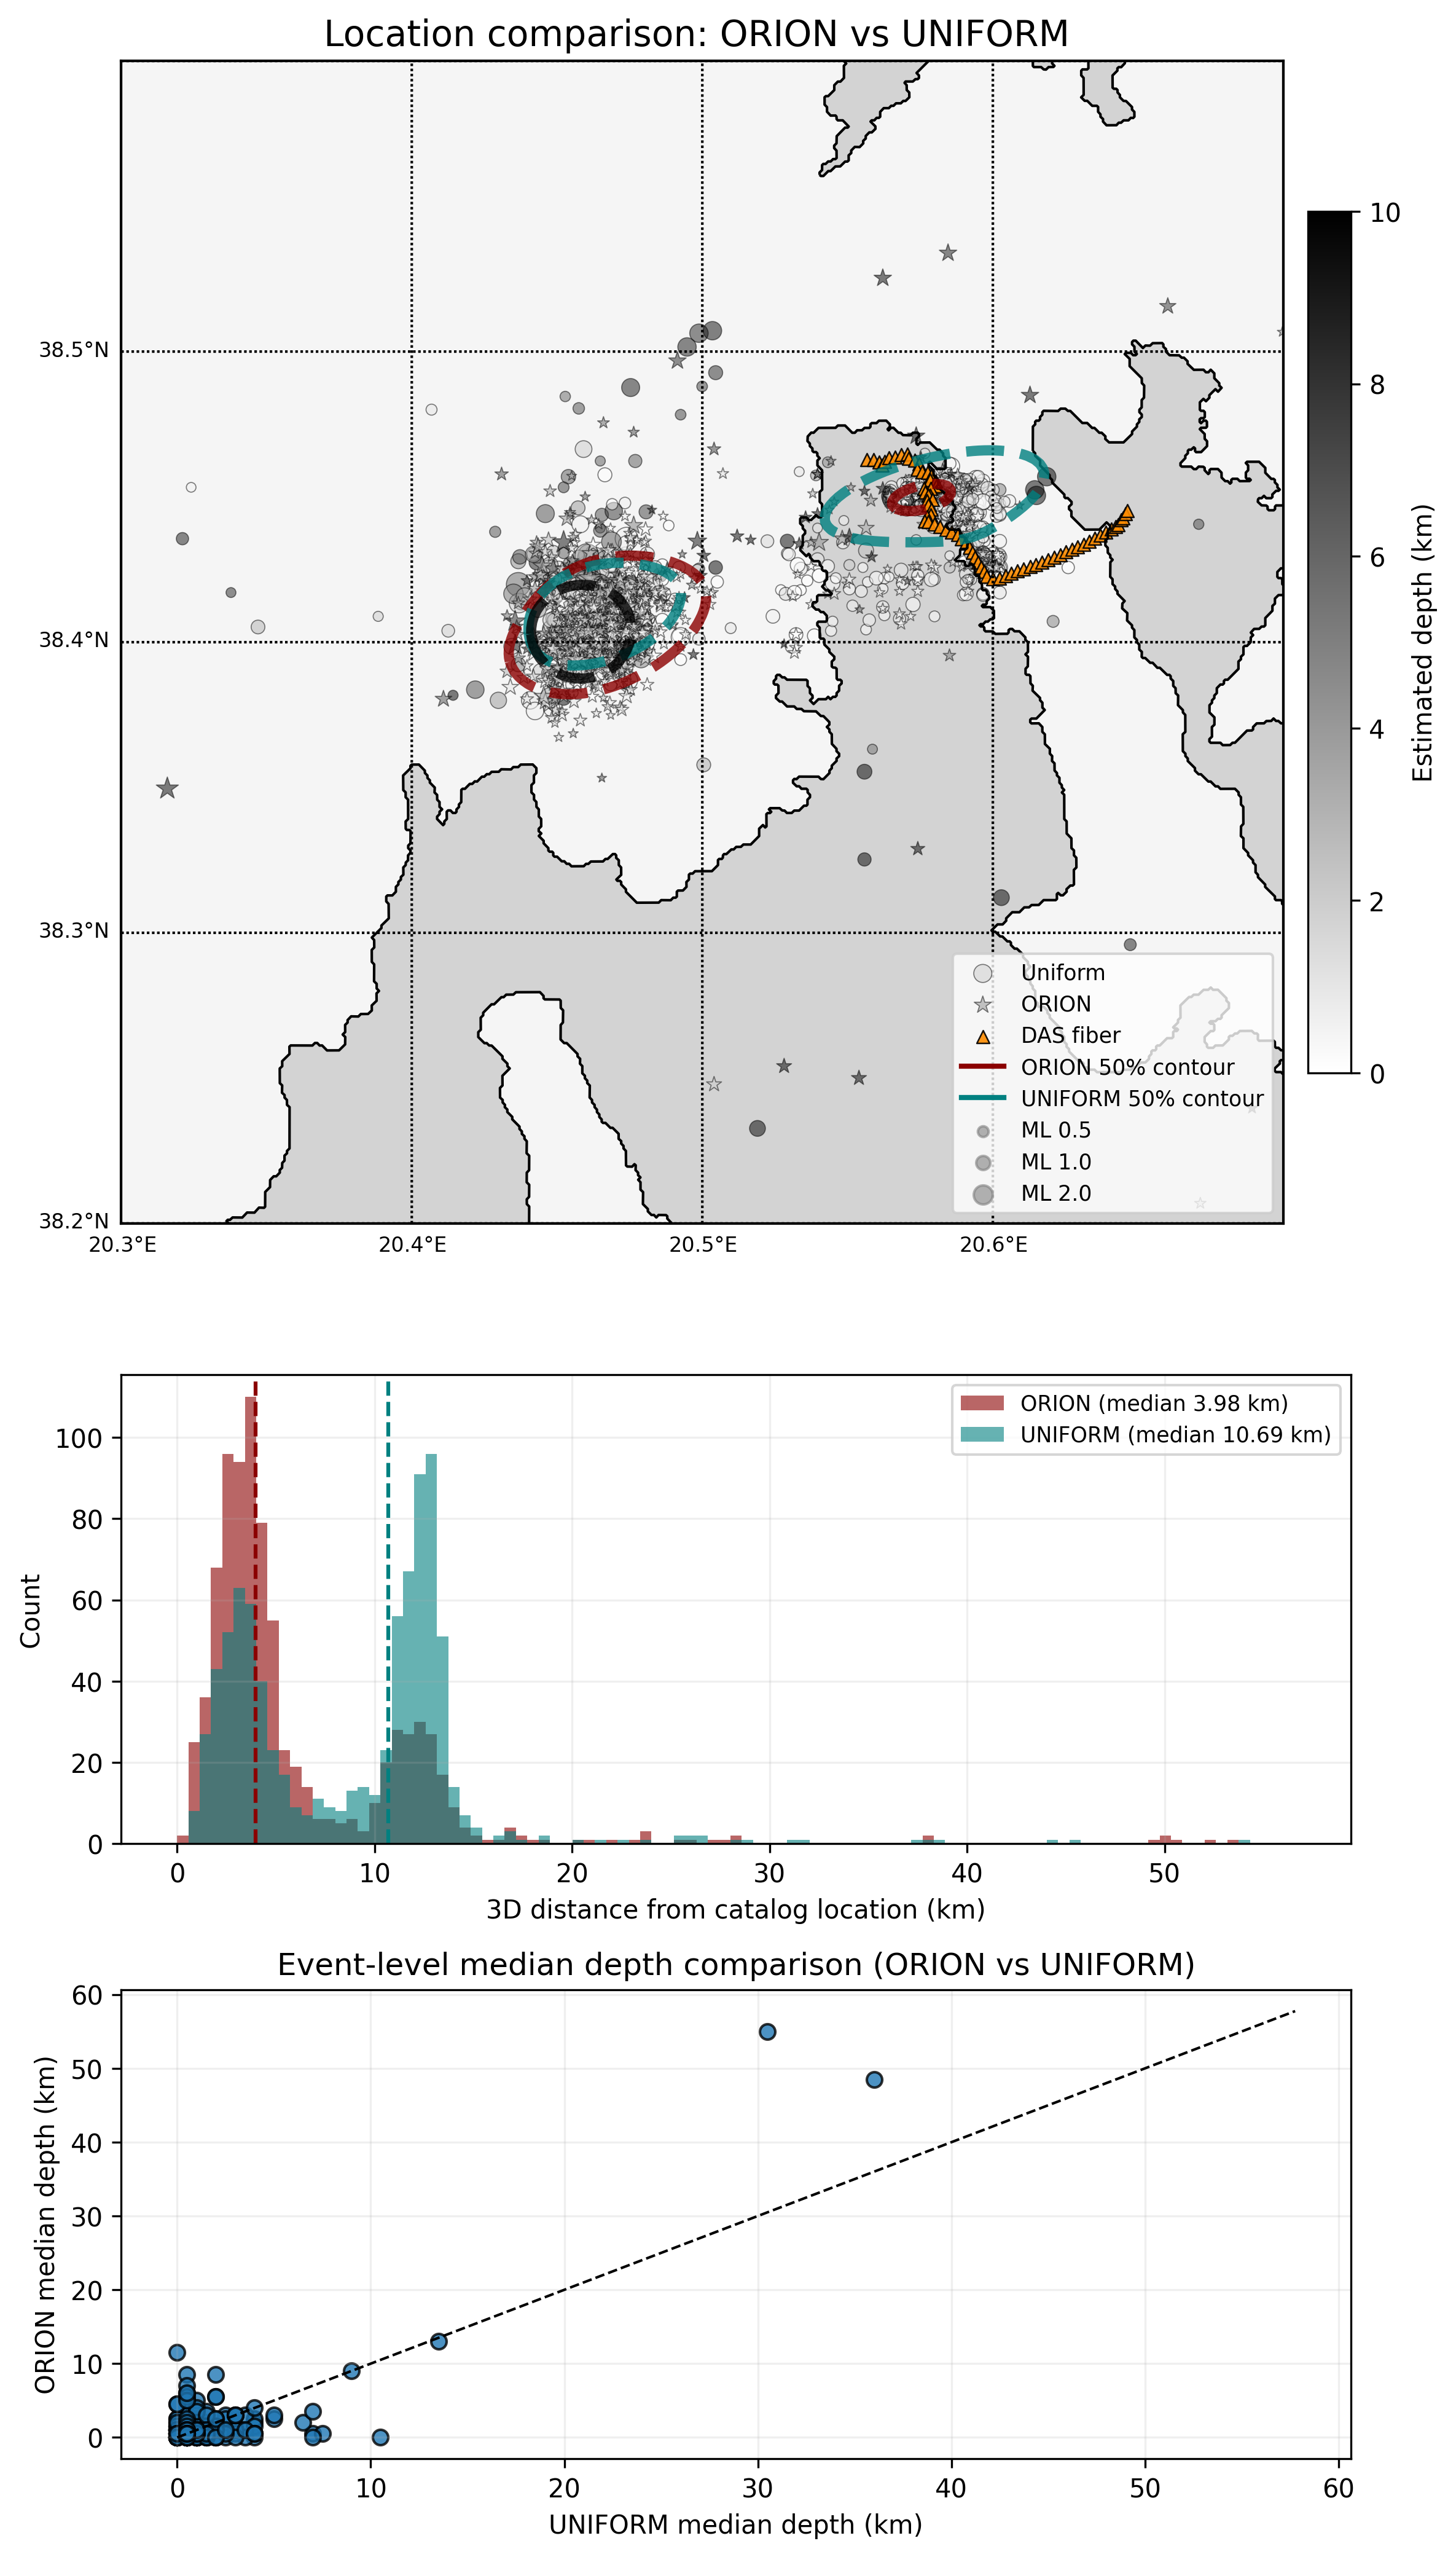

Saved orion_uniform_map_hist_scatter.pdf


In [12]:
plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',
    title="Location comparison: ORION vs UNIFORM "
)


In [6]:
def plot_fiber_only_map_with_maxima_no_cat(ref_lat, ref_lon, das_hyb,
                                           earthquake_location, cartesian_grid_x,
                                           cartesian_grid_y, lat_range, lon_range,
                                           parent_folder,
                                           hybrid2_parent_folder,
                                           title="Fiber Maxima Map",
                                           magnitude_threshold=0.0):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(parent_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(parent_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_gilbert(parent_folder, event_id):
        event_path = os.path.join(parent_folder, event_id, 'hybrid_gilbert')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = "corrmatrix_trial_*_hybrid.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations


    # ✅ ADAPTED FUNCTION FOR HYBRID_GILBERT FILES
    def collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id):
        event_path = os.path.join(hybrid2_parent_folder, event_id, 'hybrid_gilbert')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        # Adapted pattern for "corrmatrix_trial-0-hybrid.npy"
        pattern = "corrmatrix_trial_*_hybrid.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]

        ax.contour(xgrid, ygrid, kde_vals, levels=[level],
                colors='black', linestyles='dashed', linewidths=8, alpha=0.5)
        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level],
                            colors=[color], linestyles='dashed', linewidths=6, alpha=0.9, **kwargs)
        if contour.collections:
            return contour.collections[0]
        return None

    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=2, scale_factor=50):
        return base_size + scale_factor * mag

    fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=400)
    axes = axes.flatten()

    map_titles = [
        'Stations',
        'Fiber + ORION',
        'Hybrid (sum)',
        'Fiber + uniform',
        'Hybrid gilbert',
        'Hybrid2 (ORION + stations)'
    ]
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid_gilbert', 'hybrid_gilbert', 'hybrid_gilbert', 'mediumorchid', 'Hybrid_gilbert')],
        [('hybrid2', None, None, 'green', 'Hybrid2')]
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    for idx, (ax, variants, map_title) in enumerate(zip(axes, variant_groups, map_titles)):
        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        if idx in [1,2,3,4,5]:
                            ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                    color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                    label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        if idx in [0, 2, 4, 5]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["longitude"], df_stations["latitude"], marker='^',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        catalog_lats = catalog_df['latitude'].values
        catalog_lons = catalog_df['longitude'].values
        ax.scatter(catalog_lons, catalog_lats, marker='o', color='black', s=30,
                label='Catalog', alpha=0.7, edgecolor='k', linewidth=0.5)

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue
            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                elif key == 'hybrid2':
                    points = collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id)
                elif key == 'hybrid_gilbert':
                    points = collect_refined_max_locations_for_hybrid_gilbert(parent_folder, event_id)


                else:
                    points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                contour = plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE")
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                              markerfacecolor=color, markeredgecolor='k', markersize=10))

        if idx in [1, 2, 3, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                        markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                    label='Catalog earthquake locations \n (Bocchini et al., 2025 in prep.)',
                                    markerfacecolor='black', markeredgecolor='k', markersize=2))
        ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

    if len(variant_groups) < len(axes):
        for i in range(len(variant_groups), len(axes)):
            fig.delaxes(axes[i])

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    plt.show()



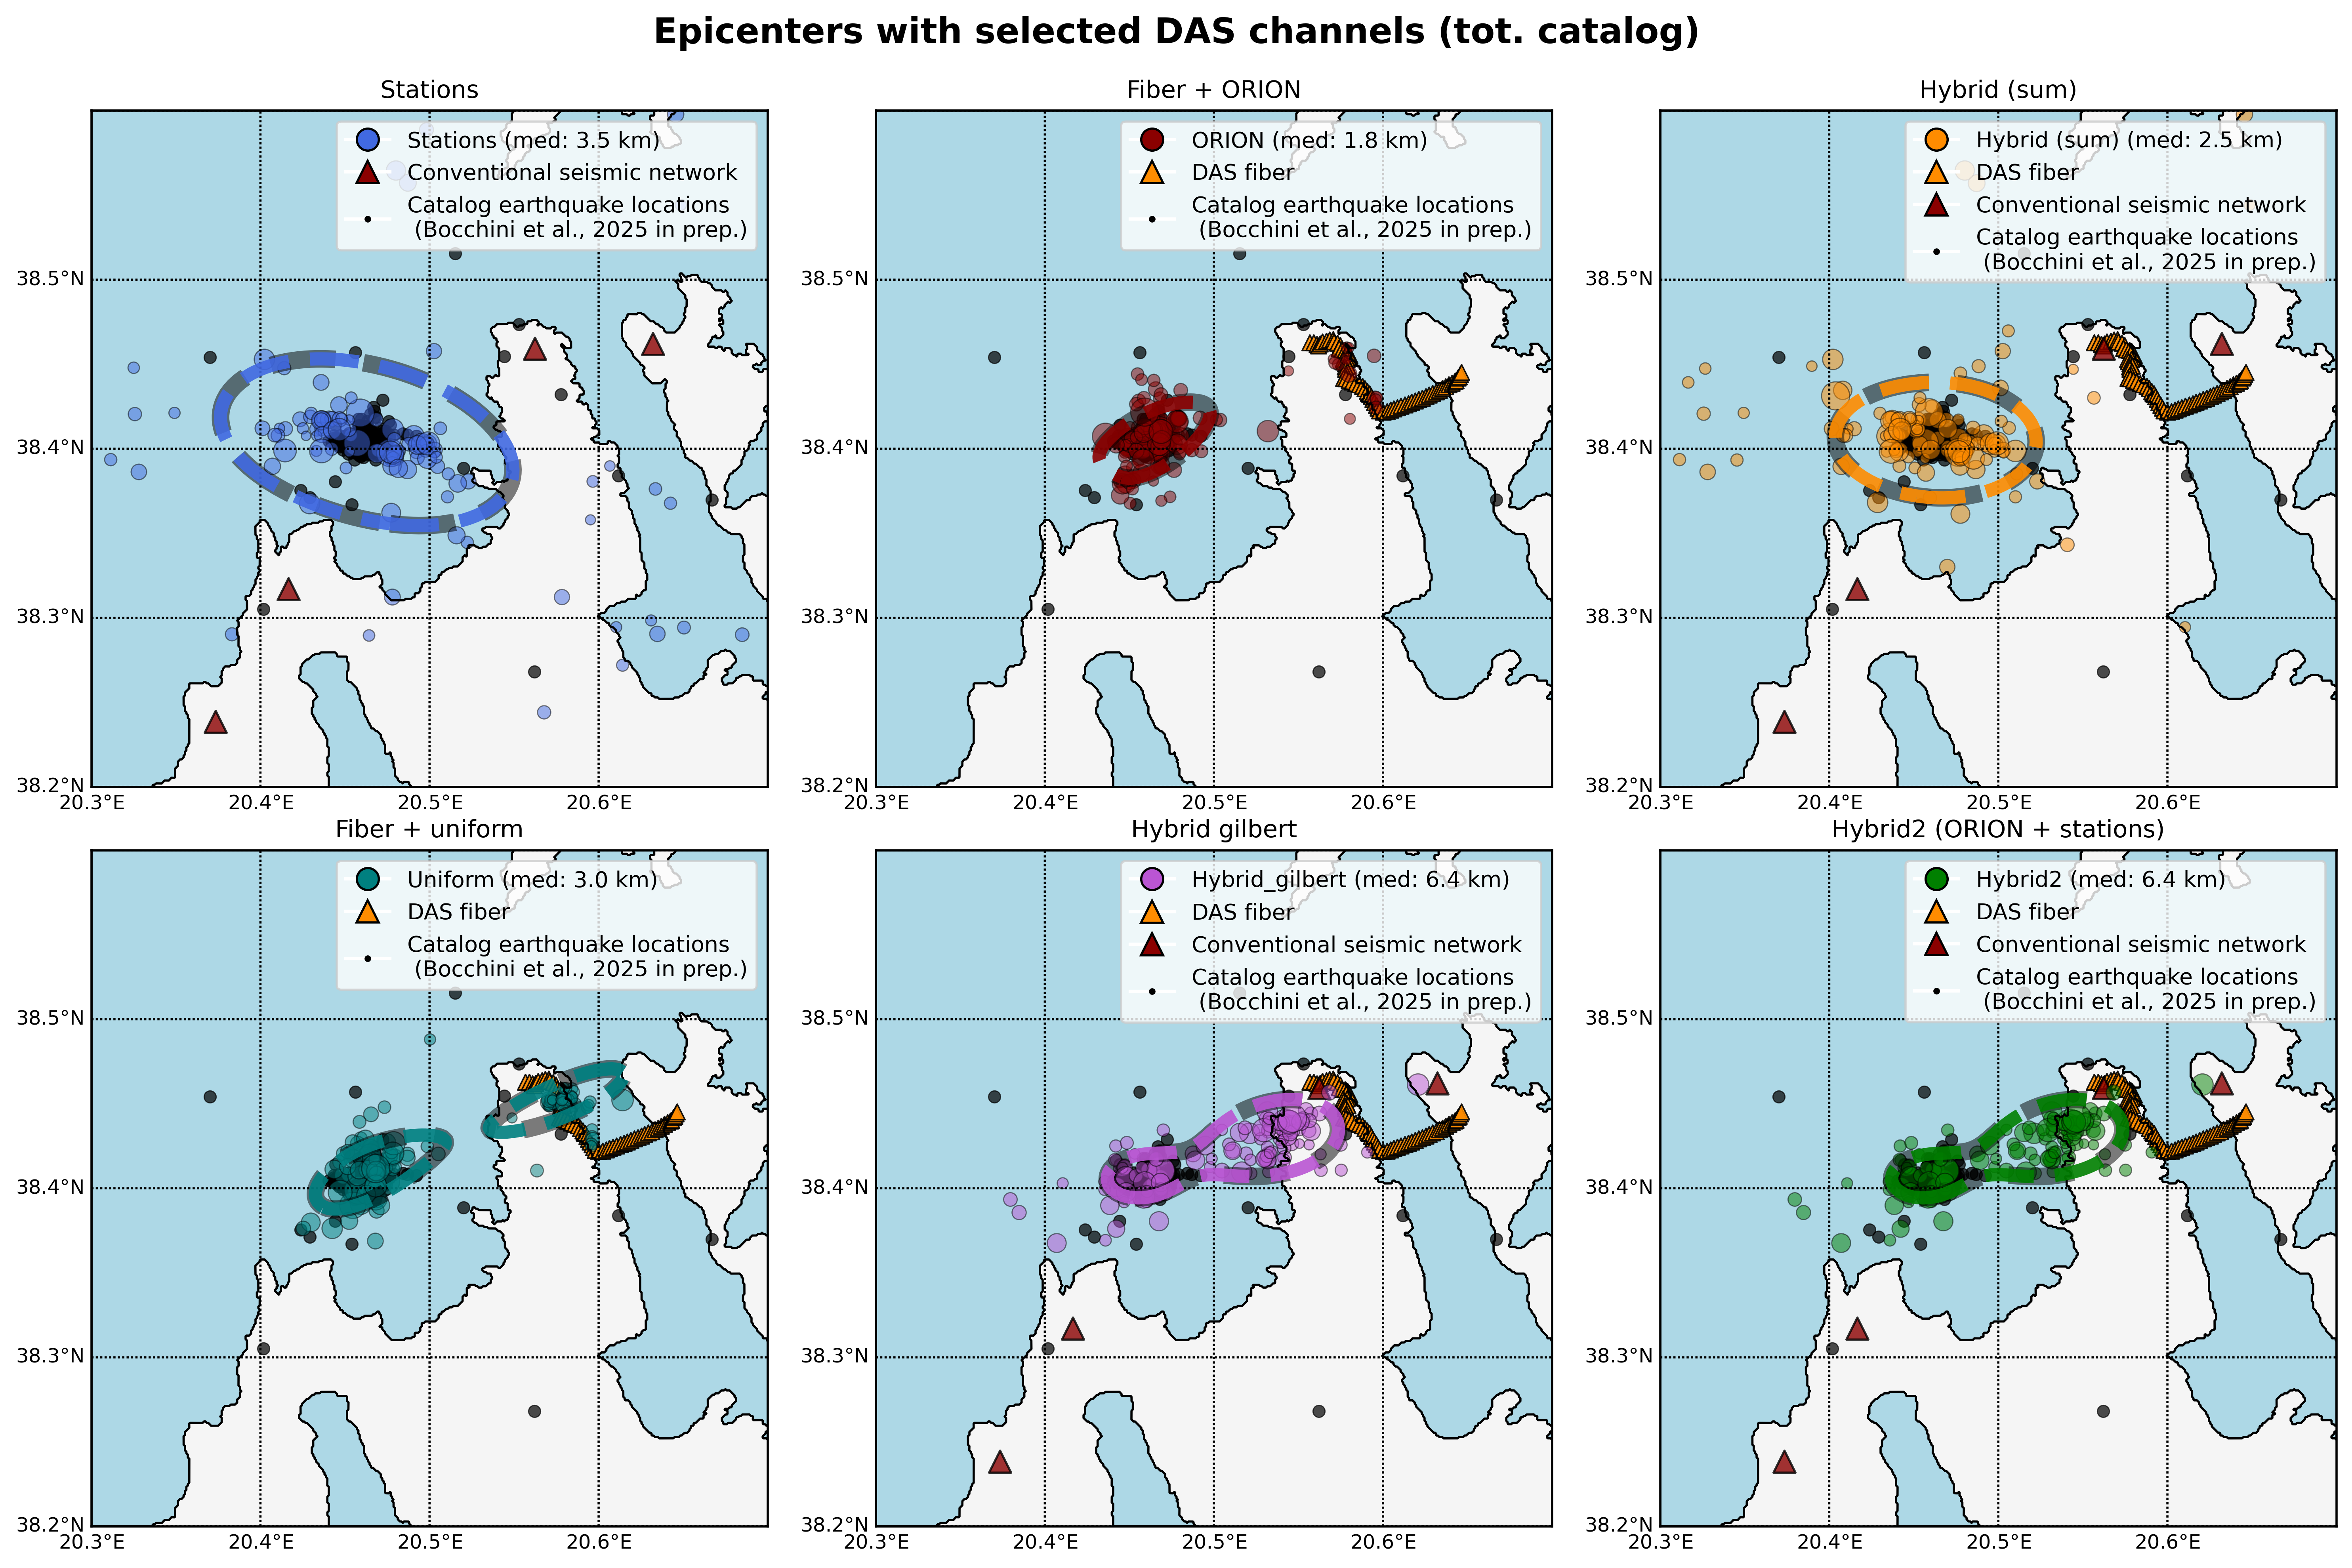

In [ ]:
plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_gilbert/',
    hybrid2_parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',  # <-- new argument
    title="Epicenters with selected DAS channels (tot. catalog)"
)


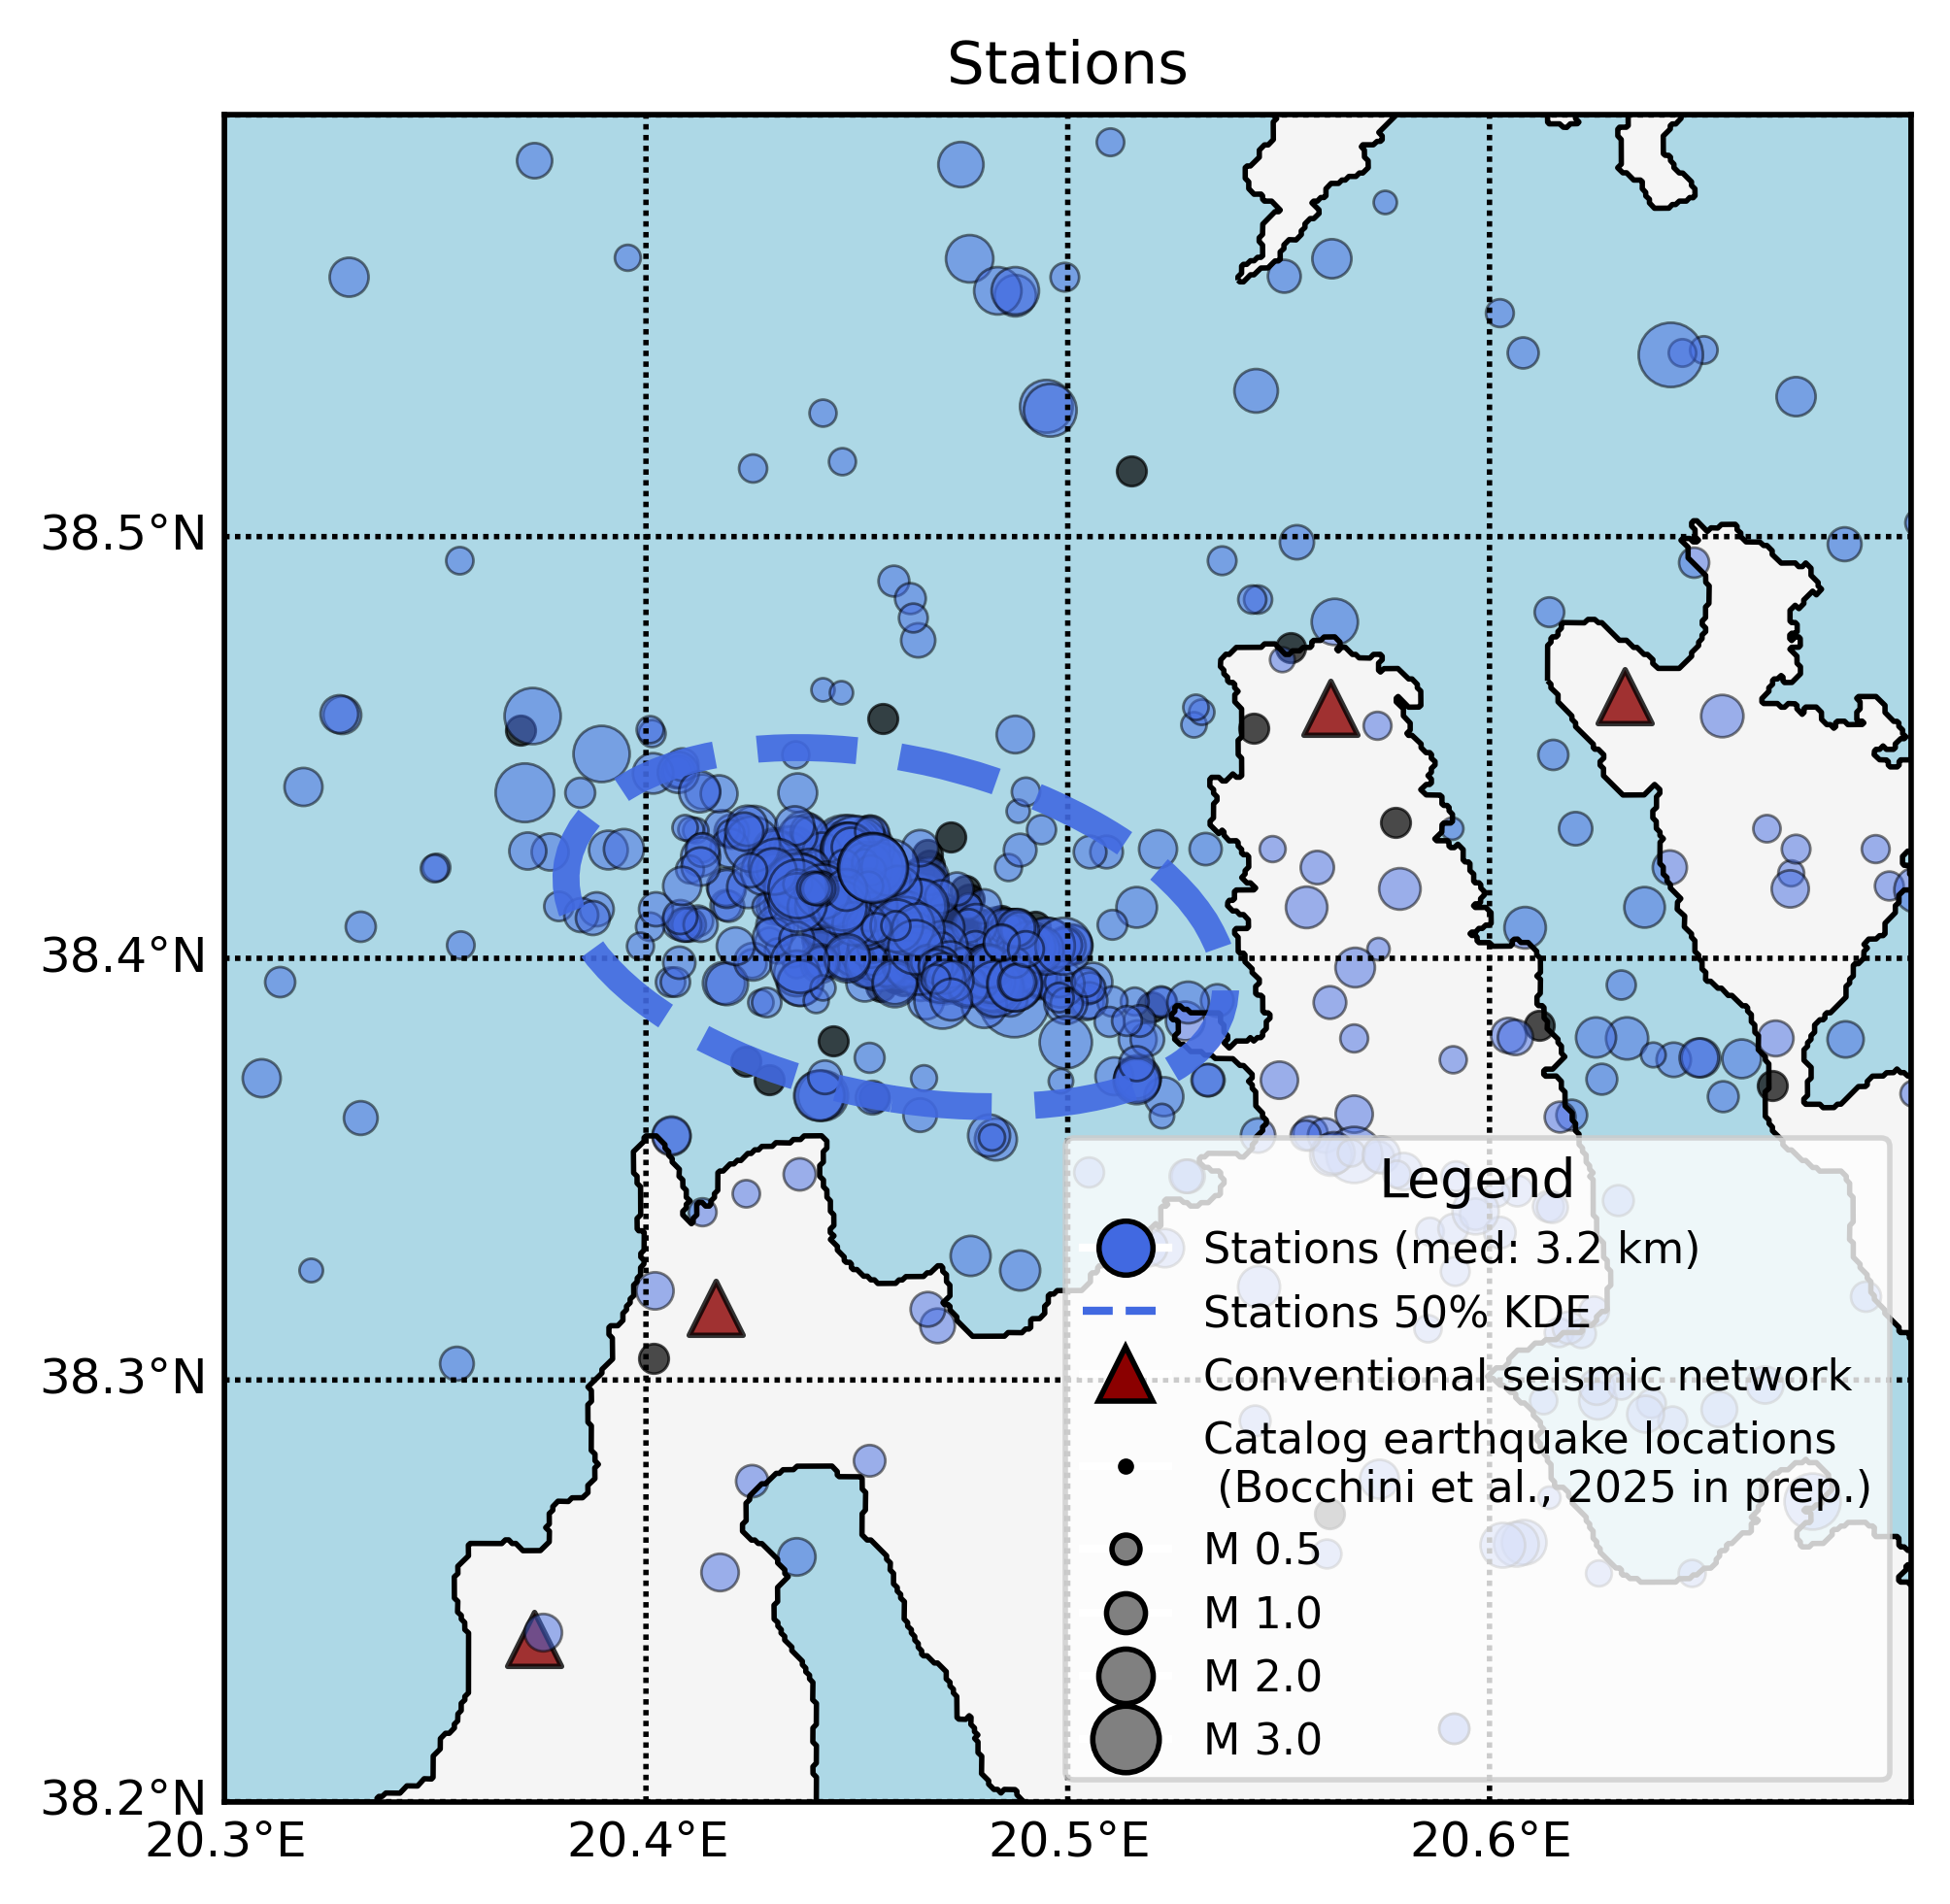

KeyboardInterrupt: 

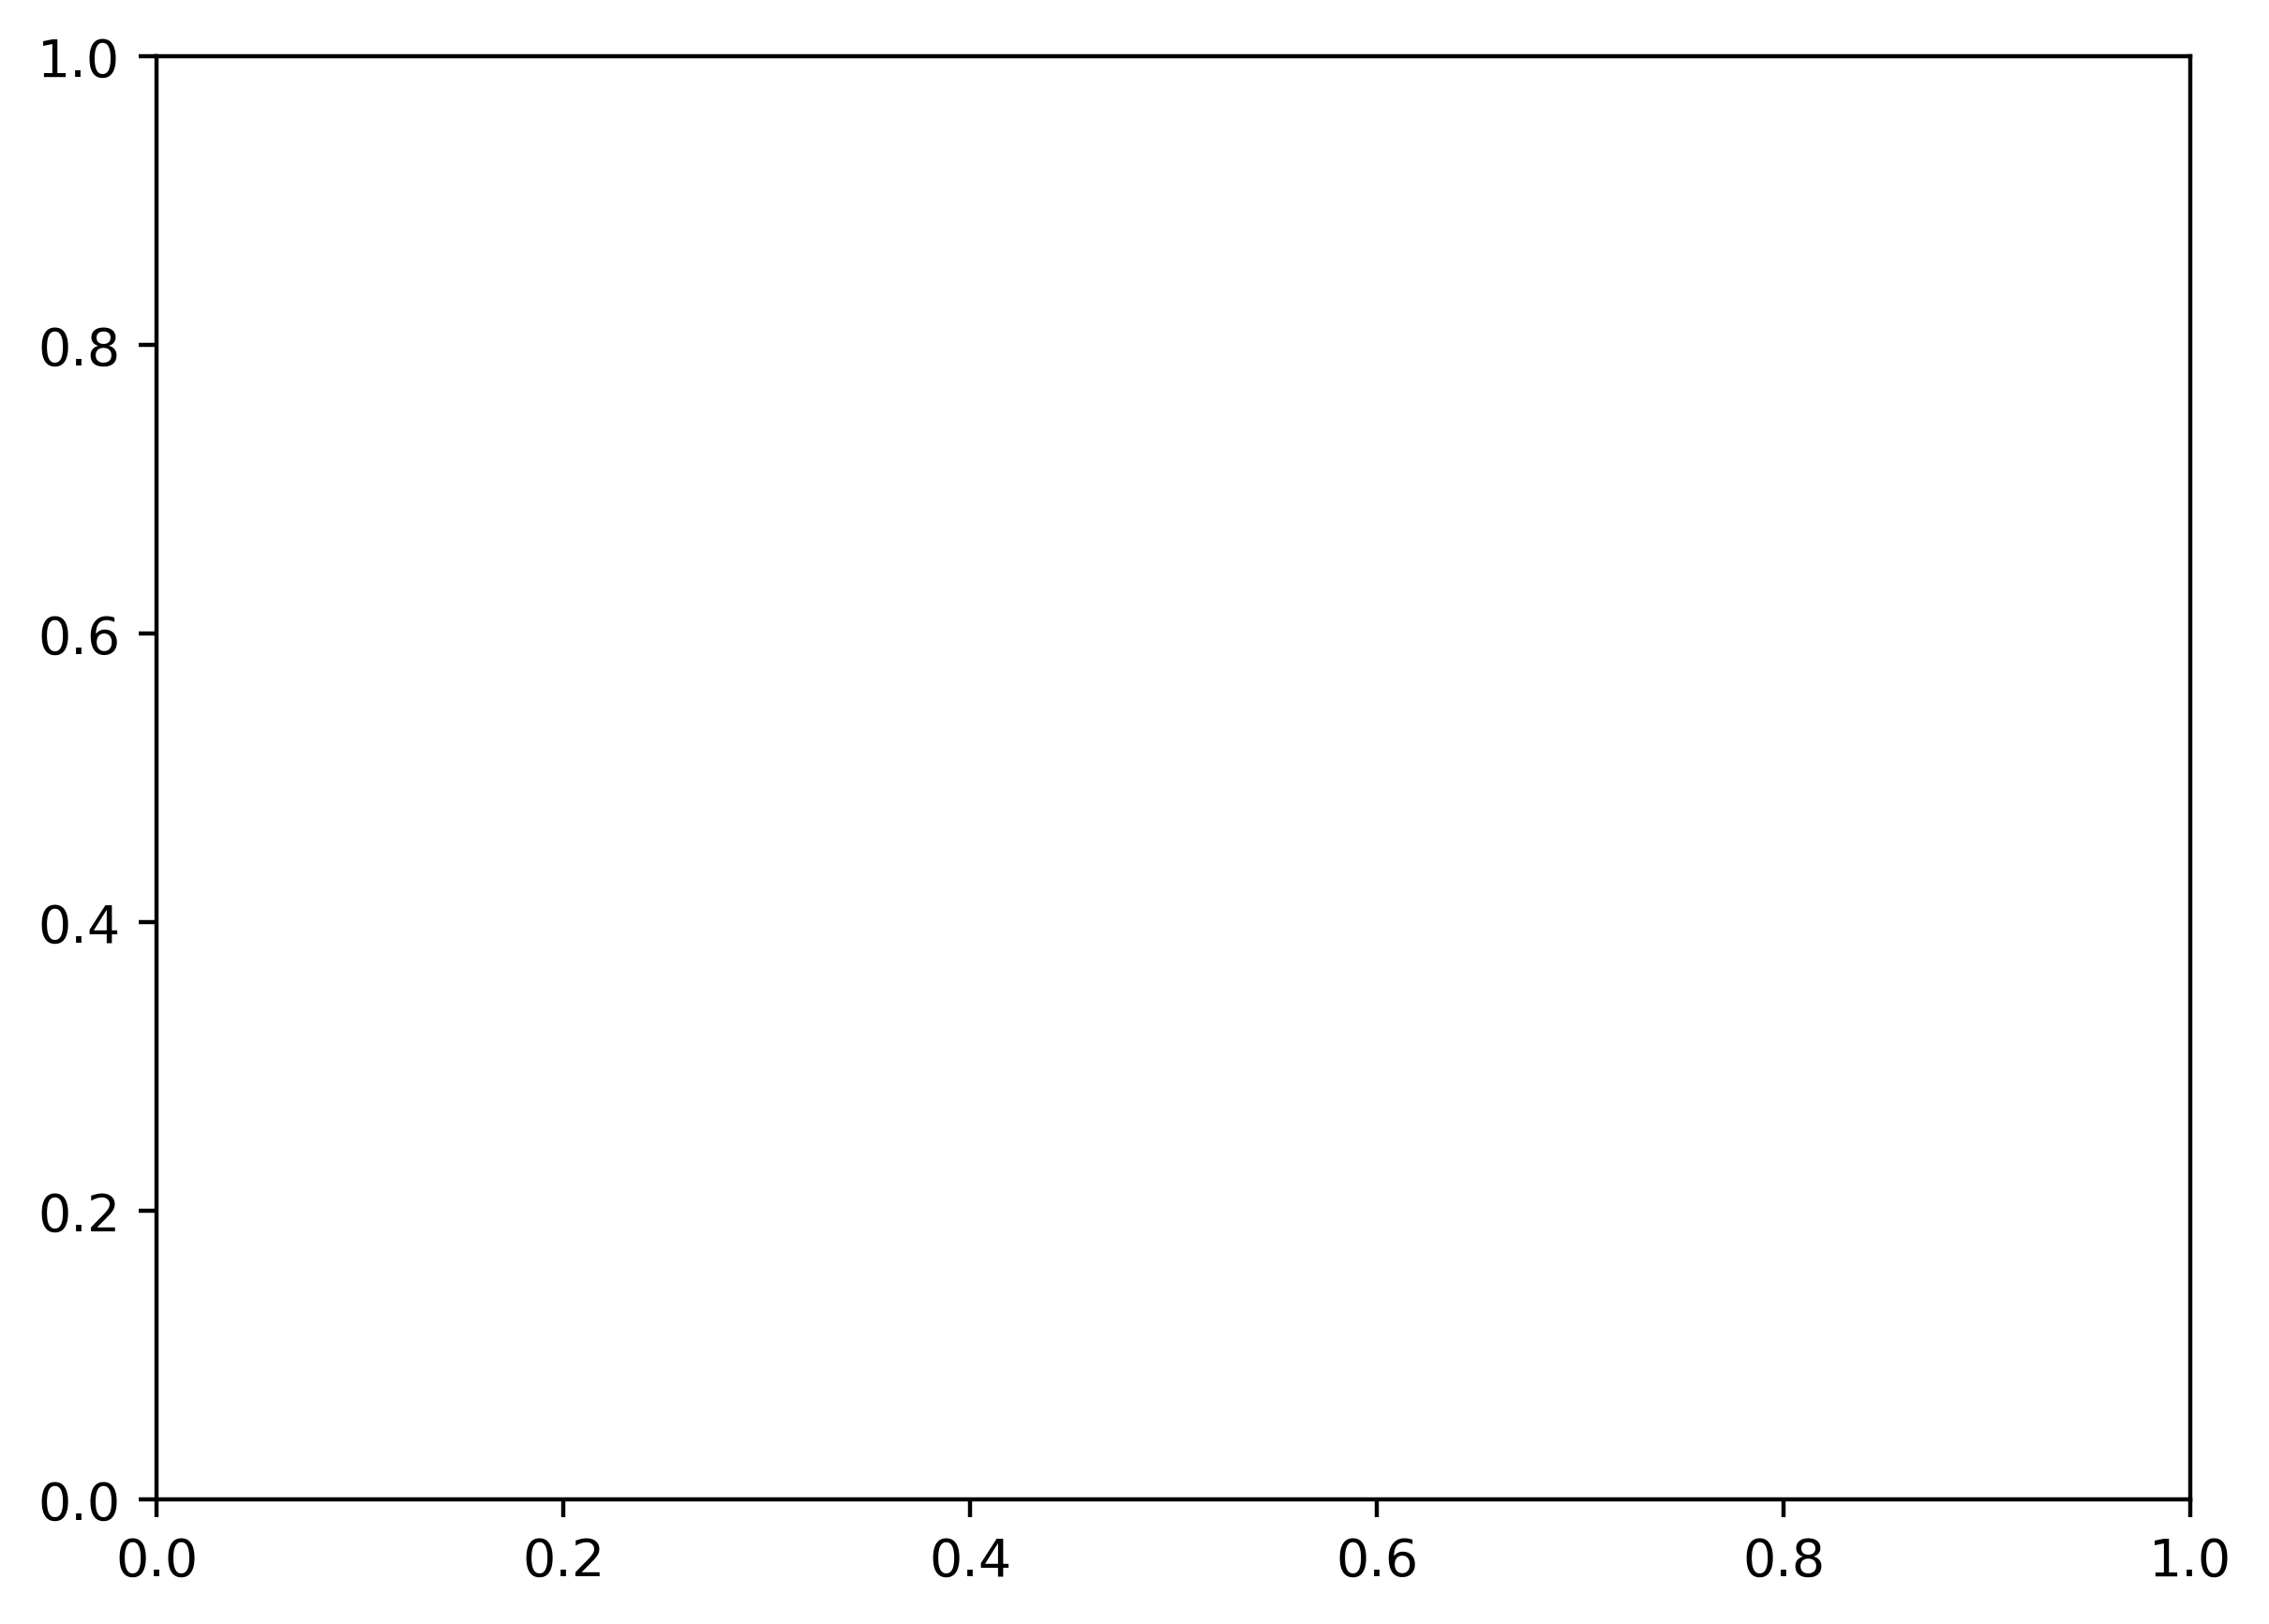

In [3]:
def plot_fiber_only_map_with_maxima_no_cat(
    ref_lat, ref_lon, das_hyb,
    earthquake_location, cartesian_grid_x,
    cartesian_grid_y, lat_range, lon_range,
    parent_folder,
    hybrid2_parent_folder,
    title="Fiber Maxima Map",
    magnitude_threshold=0.0
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    # ---------------------- HELPER FUNCTIONS ----------------------
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(parent_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(parent_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id):
        event_path = os.path.join(hybrid2_parent_folder, event_id, 'hybrid2')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = "corrmatrix_trial_*_hybrid.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]

        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level],
                             colors=[color], linestyles='dashed', linewidths=5, alpha=0.9, **kwargs)
        if contour.collections:
            return contour.collections[0]
        return None

    # ---------------------- DATA LOADING ----------------------
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=2, scale_factor=50):
        return base_size + scale_factor * mag

    map_titles = [
        'Stations',
        'Fiber + ORION',
        'Hybrid (sum)',
        'Fiber + uniform',
        'Hybrid (same num. sensors)',
        'Hybrid2 (ORION + stations)'
    ]
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid', 'hybrid', 'hybrid', 'mediumorchid', 'Hybrid')],
        [('hybrid2', None, None, 'green', 'Hybrid2')]
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    # ---------------------- PLOTTING ----------------------
    for idx, (variants, map_title) in enumerate(zip(variant_groups, map_titles)):
        fig, ax = plt.subplots(figsize=(7, 5), dpi=400)

        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1),
                        labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1),
                        labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        if idx in [1, 2, 3, 4, 5]:
                            ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                       color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                       label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        if idx in [0, 2, 4, 5]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["longitude"], df_stations["latitude"], marker='^',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        catalog_lats = catalog_df['latitude'].values
        catalog_lons = catalog_df['longitude'].values
        ax.scatter(catalog_lons, catalog_lats, marker='o', color='black', s=30,
                   label='Catalog', alpha=0.7, edgecolor='k', linewidth=0.5)

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue
            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                elif key == 'hybrid2':
                    points = collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id)
                else:
                    points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(
                        haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                contour = plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE")
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label

                # Marker legend (points)
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                            markerfacecolor=color, markeredgecolor='k', markersize=10))

                # Contour legend (50% KDE line)
                legend_elements.append(Line2D([0], [0], color=color, linestyle='--', linewidth=1.5,
                                            label=f"{label} 50% KDE"))


        if idx in [1, 2, 3, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                          markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                      label='Catalog earthquake locations \n (Bocchini et al., 2025 in prep.)',
                                      markerfacecolor='black', markeredgecolor='k', markersize=2))
        
        # Example: magnitude legend
        example_mags = [0.5, 1.0, 2.0, 3.0]  # you can adjust these

        mag_handles = [
            Line2D([0], [0], marker='o', color='w', label=f"M {mag}",
                markerfacecolor='gray', markeredgecolor='k',
                markersize=np.sqrt(marker_size_from_magnitude(mag)))
            for mag in example_mags
        ]


        # Combine the magnitude legend with the dataset legend
        # Combine the magnitude legend with the dataset legend
        all_legend_elements = legend_elements + mag_handles

        # Single legend call (so magnitude + dataset both appear)
        ax.legend(handles=all_legend_elements, fontsize=8, loc='lower right', title="Legend")



        plt.tight_layout()
        plt.show()  # Show each plot separately


plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',
    hybrid2_parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2_prova/',  # <-- new argument
    title="Epicenters with selected DAS channels (tot. catalog)"
)



In [ ]:
def plot_fiber_only_map_with_maxima_no_cat(
    ref_lat, ref_lon, das_hyb,
    earthquake_location, cartesian_grid_x,
    cartesian_grid_y, lat_range, lon_range,
    parent_folder,
    hybrid2_parent_folder,
    title="Fiber Maxima Map",
    magnitude_threshold=0.0
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    # ---------------------- HELPER FUNCTIONS ----------------------
    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(parent_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(parent_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(parent_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id):
        event_path = os.path.join(hybrid2_parent_folder, event_id, 'hybrid2')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = "corrmatrix_trial_*_hybrid.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)
                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]
                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]

        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level],
                             colors=[color], linestyles='dashed', linewidths=5, alpha=0.9, **kwargs)
        if contour.collections:
            return contour.collections[0]
        return None

    # ---------------------- DATA LOADING ----------------------
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=2, scale_factor=50):
        return base_size + scale_factor * mag

    map_titles = [
        'Stations',
        'Fiber + ORION',
        'Hybrid (sum)',
        'Fiber + uniform',
        'Hybrid (same num. sensors)',
        'Hybrid2 (ORION + stations)'
    ]
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid', 'hybrid', 'hybrid', 'mediumorchid', 'Hybrid')],
        [('hybrid2', None, None, 'green', 'Hybrid2')]
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    # ---------------------- PLOTTING ----------------------
    for idx, (variants, map_title) in enumerate(zip(variant_groups, map_titles)):
        fig, ax = plt.subplots(figsize=(7, 5), dpi=400)

        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1),
                        labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1),
                        labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        if idx in [1, 2, 3, 4, 5]:
                            ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                       color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                       label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        if idx in [0, 2, 4, 5]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["longitude"], df_stations["latitude"], marker='^',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        catalog_lats = catalog_df['latitude'].values
        catalog_lons = catalog_df['longitude'].values
        ax.scatter(catalog_lons, catalog_lats, marker='o', color='black', s=30,
                   label='Catalog', alpha=0.7, edgecolor='k', linewidth=0.5)

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue
            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                elif key == 'hybrid2':
                    points = collect_refined_max_locations_for_hybrid2(hybrid2_parent_folder, event_id)
                else:
                    points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(
                        haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                contour = plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE")
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label

                # Marker legend (points)
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                            markerfacecolor=color, markeredgecolor='k', markersize=10))

                # Contour legend (50% KDE line)
                legend_elements.append(Line2D([0], [0], color=color, linestyle='--', linewidth=1.5,
                                            label=f"{label} 50% KDE"))


        if idx in [1, 2, 3, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                          markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4, 5]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                      label='Catalog earthquake locations \n (Bocchini et al., 2025 in prep.)',
                                      markerfacecolor='black', markeredgecolor='k', markersize=2))
        
        # Example: magnitude legend
        example_mags = [0.5, 1.0, 2.0, 3.0]  # you can adjust these
        size_scale = 20  # this must match your actual size scaling
        mag_handles = [
            Line2D([0], [0], marker='o', color='w', label=f"M {mag}",
                markerfacecolor='gray', markeredgecolor='k',
                markersize=np.sqrt(mag * size_scale))
            for mag in example_mags
        ]

        # Combine the magnitude legend with the dataset legend
        all_legend_elements = legend_elements + mag_handles
        ax.legend(handles=all_legend_elements, loc='upper right', fontsize=8, title="Legend")



        ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

        plt.tight_layout()
        plt.show()  # Show each plot separately



In [4]:
def plot_fiber_only_map_with_maxima_no_cat(
        ref_lat, ref_lon, das_hyb,
        earthquake_location, cartesian_grid_x,
        cartesian_grid_y, lat_range, lon_range,
        parent_folder,
        hybrid_base_folder=None,  # NEW PARAM
        title="Fiber Maxima Map",
        magnitude_threshold=0.0):

    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(base_folder, event_id, variant_folder_name, variant_suffix):
        event_path = os.path.join(base_folder, event_id, variant_folder_name)
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        pattern = f"corrmatrix_trial_*_{variant_suffix}.npy"
        npy_files = glob.glob(os.path.join(event_path, pattern))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def collect_refined_max_locations_for_hybrid_sum(base_folder, event_id):
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        event_orion_path = os.path.join(base_folder, event_id, 'fiber_orion')
        event_stations_path = os.path.join(base_folder, event_id, 'stations')

        if not os.path.isdir(event_orion_path) or not os.path.isdir(event_stations_path):
            return max_locations

        orion_files = sorted(glob.glob(os.path.join(event_orion_path, 'corrmatrix_trial_*_fiber.npy')))
        stations_files = sorted(glob.glob(os.path.join(event_stations_path, 'corrmatrix_trial_*_stations.npy')))

        def get_trial_num(filename):
            m = re.search(r'corrmatrix_trial_(\d+)_', filename)
            return int(m.group(1)) if m else -1

        orion_files = sorted(orion_files, key=get_trial_num)
        stations_files = sorted(stations_files, key=get_trial_num)

        for ofile, sfile in zip(orion_files, stations_files):
            if get_trial_num(ofile) != get_trial_num(sfile):
                continue

            try:
                corr_orion = np.load(ofile)
                corr_stations = np.load(sfile)

                if corr_orion.size != corr_stations.size or corr_orion.size % (nx * ny) != 0:
                    continue

                nz = corr_orion.size // (nx * ny)
                corr_orion = corr_orion.reshape((nx, ny, nz))
                corr_stations = corr_stations.reshape((nx, ny, nz))

                corr_sum = corr_orion + corr_stations
                corr_sum = corr_sum / np.nanmax(corr_sum)
                CXY = np.max(corr_sum, axis=2).T

                window_size = 15
                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 25
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label, **kwargs):
        if len(coords) < 10:
            return None
        xy = np.array(coords).T
        kde = gaussian_kde(xy)

        x_min, y_min = xy.min(axis=1)
        x_max, y_max = xy.max(axis=1)
        x_grid = np.linspace(x_min, x_max, 200)
        y_grid = np.linspace(y_min, y_max, 200)
        xgrid, ygrid = np.meshgrid(x_grid, y_grid)
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords).reshape(xgrid.shape)

        sorted_kde = np.sort(kde_vals.ravel())[::-1]
        cumsum = np.cumsum(sorted_kde) / np.sum(sorted_kde)
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]
        contour = ax.contour(xgrid, ygrid, kde_vals, levels=[level], colors=[color],
                             linestyles='dashed', alpha=0.7, **kwargs)
        return contour

    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    event_ids = [f for f in os.listdir(parent_folder)
                 if os.path.isdir(os.path.join(parent_folder, f)) and re.match(r'^kef\d+', f)]

    def marker_size_from_magnitude(mag, base_size=5, scale_factor=25):
        return base_size + scale_factor * mag

    fig, axes = plt.subplots(2, 3, figsize=(25, 12), dpi=300)
    axes = axes.flatten()

    map_titles = ['Stations', 'Fiber + ORION seletion', 'Hybrid (sum)', 
                  'Fiber + uniform selection', 'Hybrid (mix horiz. comp)']
    variant_groups = [
        [('stations', 'stations', 'stations', 'royalblue', 'Stations')],
        [('orion', 'fiber_orion', 'fiber', 'darkred', 'ORION')],
        [('hybrid_sum', None, None, 'darkorange', 'Hybrid (sum)')],
        [('uniform', 'fiber_uniform', 'fiber', 'teal', 'Uniform')],
        [('hybrid', 'hybrid', 'hybrid', 'mediumorchid', 'Hybrid')],
    ]

    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    stations_csv_path = os.path.join(das_csv_path, "stations.csv")

    for idx, (ax, variants, map_title) in enumerate(zip(axes, variant_groups, map_titles)):
        m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                    llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)
        m.drawcoastlines()
        m.drawcountries()
        m.fillcontinents(color='whitesmoke', lake_color='lightblue')
        m.drawmapboundary(fill_color='lightblue')
        m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=9)
        m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=9)
        ax.set_title(map_title, fontsize=11)

        distances = {}
        coords = {}
        legend_elements = []

        # Plot DAS fiber
        try:
            for file in os.listdir(das_csv_path):
                if file.endswith(".csv") and file != "stations.csv":
                    df_das = pd.read_csv(os.path.join(das_csv_path, file))
                    if "latitude" in df_das.columns and "longitude" in df_das.columns:
                        sampled_df = df_das.iloc[::100]
                        ax.scatter(sampled_df["longitude"], sampled_df["latitude"], marker='^',
                                   color='darkorange', linewidths=0.7, edgecolor='k', s=50, alpha=0.9,
                                   label="DAS fiber")
                    break
        except Exception as e:
            print(f"Error loading DAS CSV: {e}")

        # Plot stations (only in 1st, 3rd, 5th plot)
        if idx in [0, 2, 4]:
            try:
                df_stations = pd.read_csv(stations_csv_path)
                ax.scatter(df_stations["lon"], df_stations["lat"], marker='s',
                           color='darkred', edgecolor='k', s=100, alpha=0.8, label="Conventional seismic stations")
            except Exception as e:
                print(f"Error loading stations.csv: {e}")

        for event_id in event_ids:
            magnitude = magnitude_dict.get(event_id, None)
            if magnitude is None or magnitude < magnitude_threshold:
                continue

            marker_size = marker_size_from_magnitude(magnitude)

            for key, folder, suffix, color, label in variants:
                if key == 'hybrid_sum':
                    points = collect_refined_max_locations_for_hybrid_sum(parent_folder, event_id)
                else:
                    if folder == 'hybrid' and hybrid_base_folder is not None:
                        points = collect_refined_max_locations_for_variant(hybrid_base_folder, event_id, folder, suffix)
                    else:
                        points = collect_refined_max_locations_for_variant(parent_folder, event_id, folder, suffix)

                for lat, lon in points:
                    ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5,
                               s=marker_size, alpha=0.5)
                    distances.setdefault(key, []).append(haversine(earthquake_location[0], earthquake_location[1], lat, lon))
                    coords.setdefault(key, []).append((lon, lat))

        for key, _, _, color, label in variants:
            if key in coords:
                plot_50pct_contour(ax, coords[key], color, f"{label} 50% KDE", linewidth=10)
                if distances[key]:
                    med = np.median(distances[key])
                    label_with_med = f"{label} (med: {med:.1f} km)"
                else:
                    label_with_med = label
                legend_elements.append(Line2D([0], [0], marker='o', color='w', label=label_with_med,
                                              markerfacecolor=color, markeredgecolor='k', markersize=10))

        if idx in [1, 2, 3, 4]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='DAS fiber',
                                          markerfacecolor='darkorange', markeredgecolor='k', markersize=10))
        if idx in [0, 2, 4]:
            legend_elements.append(Line2D([0], [0], marker='^', color='w', label='Conventional seismic network',
                                          markerfacecolor='darkred', markeredgecolor='k', markersize=10))

        ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

    if len(variant_groups) < len(axes):
        for i in range(len(variant_groups), len(axes)):
            fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


In [2]:
plot_fiber_only_map_with_maxima_no_cat_single_color(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection/',
    title="LION with auto-selected DAS channels"
)


NameError: name 'cartesian_grid_x' is not defined

In [ ]:
def plot_fiber_only_map_with_maxima(ref_lat, ref_lon, das_hyb,
                                    earthquake_location, cartesian_grid_x,
                                    cartesian_grid_y, lat_range, lon_range,
                                    parent_folder,
                                    title="Fiber Maxima Map (with non-selected)"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from matplotlib import cm

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)

        a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_suffix):
        folder_name = f"{event_id}{variant_suffix}"
        event_path = os.path.join(parent_folder, folder_name, 'fiber')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                window_size = 10
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 10
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    # Load catalog
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    valid_evids = set(catalog_df['evid'].astype(str))
    evid_to_coords = {str(row['evid']): (row['latitude'], row['longitude']) for _, row in catalog_df.iterrows()}

    # Detect event IDs from folder names with _variant suffix
    folder_list = os.listdir(parent_folder)
    pattern = re.compile(r'^(.*)_(orion|random|non_selected)$')
    event_ids = set()
    for folder in folder_list:
        m = pattern.match(folder)
        if m:
            event_ids.add(m.group(1))

    event_ids = sorted(list(event_ids))
# Filter to IDs <= '0844' (preserving leading zeros)
# Filter event IDs from '0191' to '0844' inclusive
    #event_ids = sorted([
    #    eid for eid in event_ids
    #    if re.search(r'\d+', eid) and int(re.search(r'\d+', eid).group()) <= 845
    #])

    total_events = len(event_ids)

    # Assign colors
    tab20c_colors = cm.get_cmap('tab20').colors
    event_color_map = {}
    for i, eid in enumerate(event_ids):
        color = tab20c_colors[i % len(tab20c_colors)] if i < len(tab20c_colors) else (0.5, 0.5, 0.5)
        event_color_map[eid] = color

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1, 0, 0, 0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0, 0, 0, 1], fontsize=8)

    # Global distance lists
    all_dists_orion = []
    all_dists_random = []
    all_dists_non_selected = []

    for event_id in event_ids:
        color = event_color_map[event_id]
        has_catalog = event_id in evid_to_coords

        if has_catalog:
            lat_cat, lon_cat = evid_to_coords[event_id]
            ax.scatter(lon_cat, lat_cat, marker='*', color=color, edgecolor='k', linewidths=1, s=40, alpha=0.7, label=f"{event_id} Catalog")
        else:
            print(f"[info] No catalog location for event {event_id}")
            lat_cat, lon_cat = None, None

        # Orion
        orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
        for lat, lon in orion_pts:
            ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Orion")
            if lat_cat is not None:
                all_dists_orion.append(haversine(lat_cat, lon_cat, lat, lon))

        # Random
        random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
        for lat, lon in random_pts:
            ax.scatter(lon, lat, marker='s', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Random")
            if lat_cat is not None:
                all_dists_random.append(haversine(lat_cat, lon_cat, lat, lon))

        # Non-selected
        non_selected_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_non_selected')
        for lat, lon in non_selected_pts:
            ax.scatter(lon, lat, marker='x', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Non-selected")
            if lat_cat is not None:
                all_dists_non_selected.append(haversine(lat_cat, lon_cat, lat, lon))

    # Distance stats
    if all_dists_orion:
        print(f"[GLOBAL] Mean Orion distance: {np.mean(all_dists_orion):.2f} km")
    if all_dists_random:
        print(f"[GLOBAL] Mean Random distance: {np.mean(all_dists_random):.2f} km")
    if all_dists_non_selected:
        print(f"[GLOBAL] Mean Non-selected distance: {np.mean(all_dists_non_selected):.2f} km")

    # DAS station locations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='^', color='black', edgecolor='k', s=25, label='DAS fiber')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    #ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize='x-small', frameon=True)

    # Orion histogram
    if all_dists_orion:
        fig_orion, ax_orion = plt.subplots(figsize=(6, 4), dpi=150)
        ax_orion.hist(all_dists_orion, bins=20, color='blue', edgecolor='black', alpha=0.7)
        ax_orion.axvline(np.median(all_dists_orion), color='red', linestyle='--', label=f"Median = {np.median(all_dists_orion):.2f} km")
        ax_orion.set_title("Histogram of Orion Maxima Distances")
        ax_orion.set_xlabel("Distance from Catalog Location (km)")
        ax_orion.set_ylabel("Number of Maxima")
        ax_orion.set_ylim([0, 100])
        ax_orion.legend()
        ax_orion.grid(True)

    # Random histogram
    if all_dists_random:
        fig_random, ax_random = plt.subplots(figsize=(6, 4), dpi=150)
        ax_random.hist(all_dists_random, bins=20, color='green', edgecolor='black', alpha=0.7)
        ax_random.axvline(np.median(all_dists_random), color='red', linestyle='--', label=f"Median = {np.median(all_dists_random):.2f} km")
        ax_random.set_title("Histogram of Random Maxima Distances")
        ax_random.set_xlabel("Distance from Catalog Location (km)")
        ax_random.set_ylabel("Number of Maxima")
        ax_random.set_ylim([0, 100])
        ax_random.legend()
        ax_random.grid(True)

    # Non-selected histogram
    if all_dists_non_selected:
        fig_non, ax_non = plt.subplots(figsize=(6, 4), dpi=150)
        ax_non.hist(all_dists_non_selected, bins=20, color='orange', edgecolor='black', alpha=0.7)
        ax_non.axvline(np.median(all_dists_non_selected), color='red', linestyle='--', label=f"Median = {np.median(all_dists_non_selected):.2f} km")
        ax_non.set_title("Histogram of Non-selected Maxima Distances")
        ax_non.set_xlabel("Distance from Catalog Location (km)")
        ax_non.set_ylabel("Number of Maxima")
        ax_non.set_ylim([0, 100])
        ax_non.legend()
        ax_non.grid(True)

    plt.show()


[info] No catalog location for event kef0021


/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:162: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


[info] No catalog location for event kef0191
[info] No catalog location for event kef0200
[info] No catalog location for event kef0225
[info] No catalog location for event kef0273
[info] No catalog location for event kef0279
[info] No catalog location for event kef0413
[info] No catalog location for event kef0584
[info] No catalog location for event kef0752
[info] No catalog location for event kef1379
[info] No catalog location for event kef1401
[info] No catalog location for event kef1449
[info] No catalog location for event kef1677
[GLOBAL] Mean Orion distance: 4.60 km
[GLOBAL] Mean Random distance: 5.86 km
[GLOBAL] Mean Non-selected distance: 4.22 km


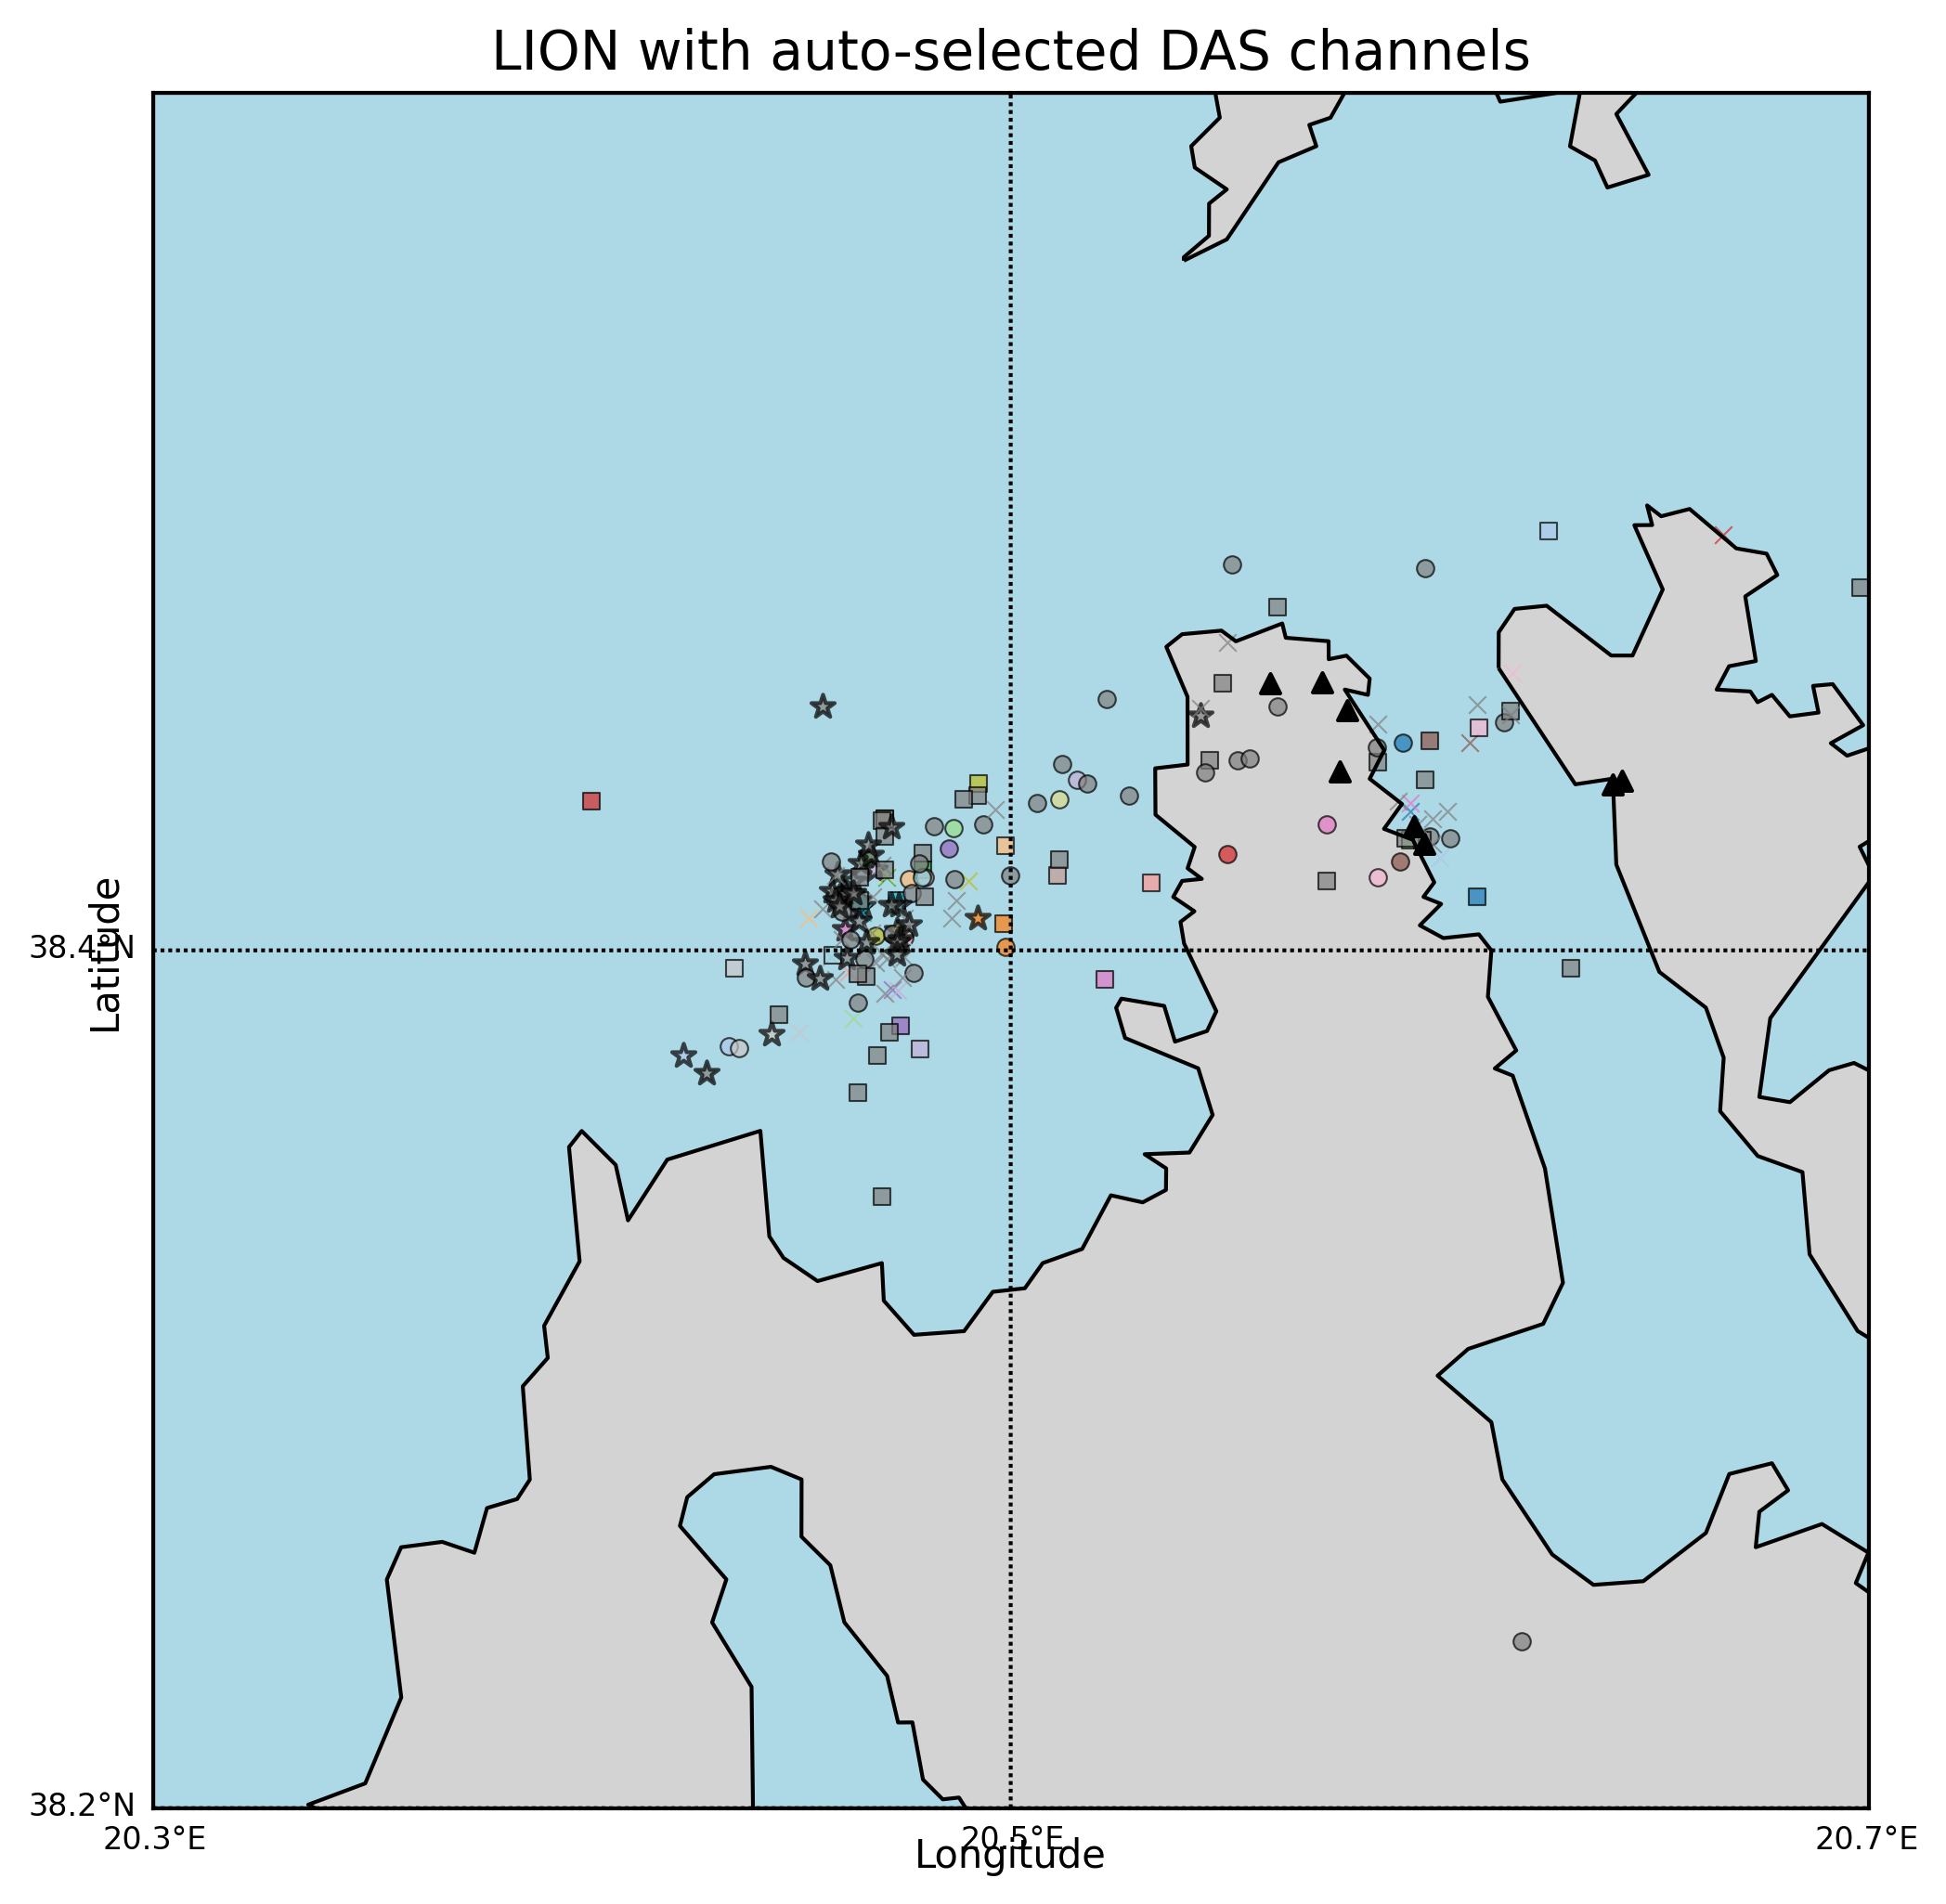

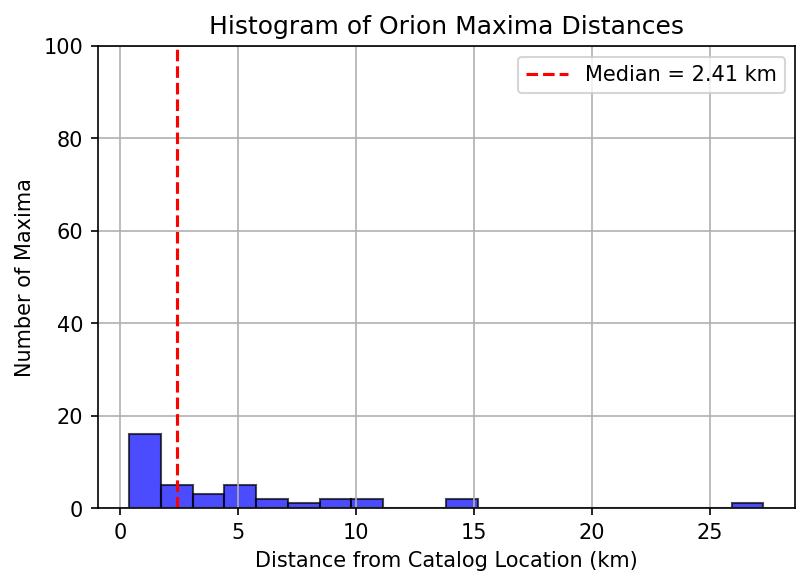

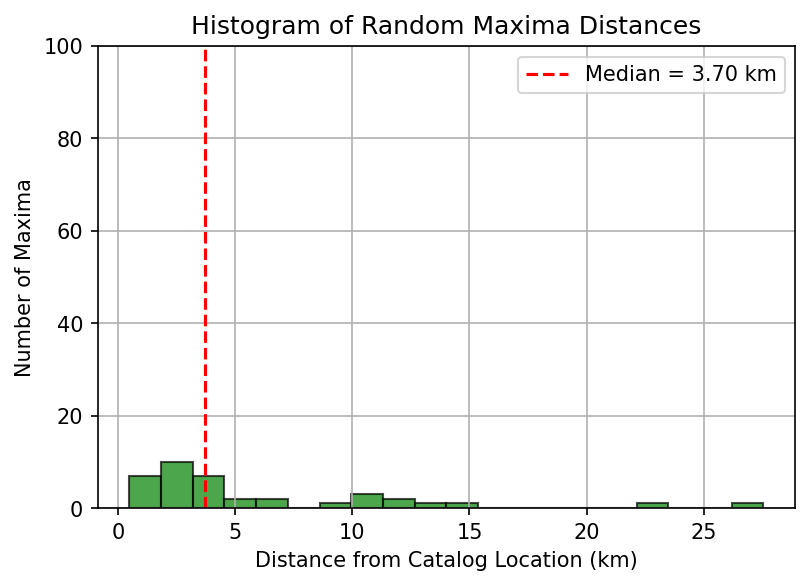

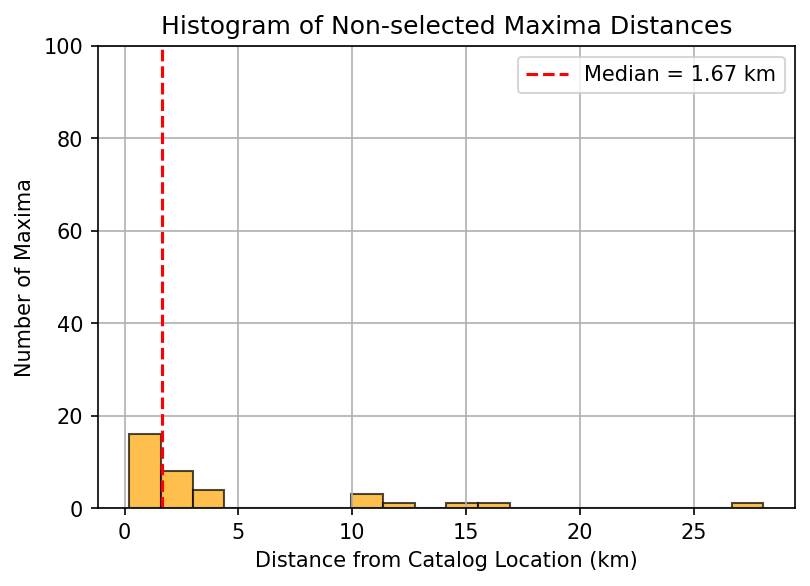

In [9]:
plot_fiber_only_map_with_maxima(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected/',
    title="LION with auto-selected DAS channels"
)


In [37]:
def plot_fiber_only_map_with_percentile_sum(ref_lat, ref_lon, das_hyb,
                                            earthquake_location, cartesian_grid_x,
                                            cartesian_grid_y, lat_range, lon_range,
                                            parent_folder, title="Fiber 99th Percentile Sum Map"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.colors import Normalize
    from matplotlib import cm
    from scipy.interpolate import griddata
    import numpy as np
    import os
    import glob

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def collect_percentile_sum(folder_path):
        nx, ny = cartesian_grid_x.shape
        percentile_sum = np.zeros((ny, nx))  # Shape: (lat, lon)

        for event_folder in os.listdir(folder_path):
            event_path = os.path.join(folder_path, event_folder, 'fiber')
            if not os.path.isdir(event_path):
                continue

            npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))
            for file in npy_files:
                try:
                    corrmatrix_das = np.load(file)
                    total_size = corrmatrix_das.size
                    if total_size % (nx * ny) != 0:
                        raise ValueError(f"File {file} shape is incompatible with grid size.")

                    nz = total_size // (nx * ny)
                    corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                    corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                    CXY = np.nanpercentile(corrmatrix, 99, axis=2).T  # Shape: (ny, nx)
                    percentile_sum += np.nan_to_num(CXY)
                except Exception as e:
                    print(f"Failed to process {file}: {e}")
        return percentile_sum

    percentile_sum = collect_percentile_sum(parent_folder)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    # Convert grid to lat/lon
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    # Plot 99th percentile summed heatmap
    norm = Normalize(vmin=np.min(percentile_sum), vmax=np.max(percentile_sum))
    sc = ax.pcolormesh(lon_grid, lat_grid, percentile_sum, cmap=cm.inferno, shading='auto', norm=norm)

    # Plot earthquake catalog location
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Cluster Location')

    # Plot DAS HYB stations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Summed 99th Percentile Coherence")

    ax.legend(loc='lower right', fontsize='small', frameon=True)
    plt.savefig("fiber_99th_percentile_sum_map.pdf", bbox_inches='tight')
    plt.show()


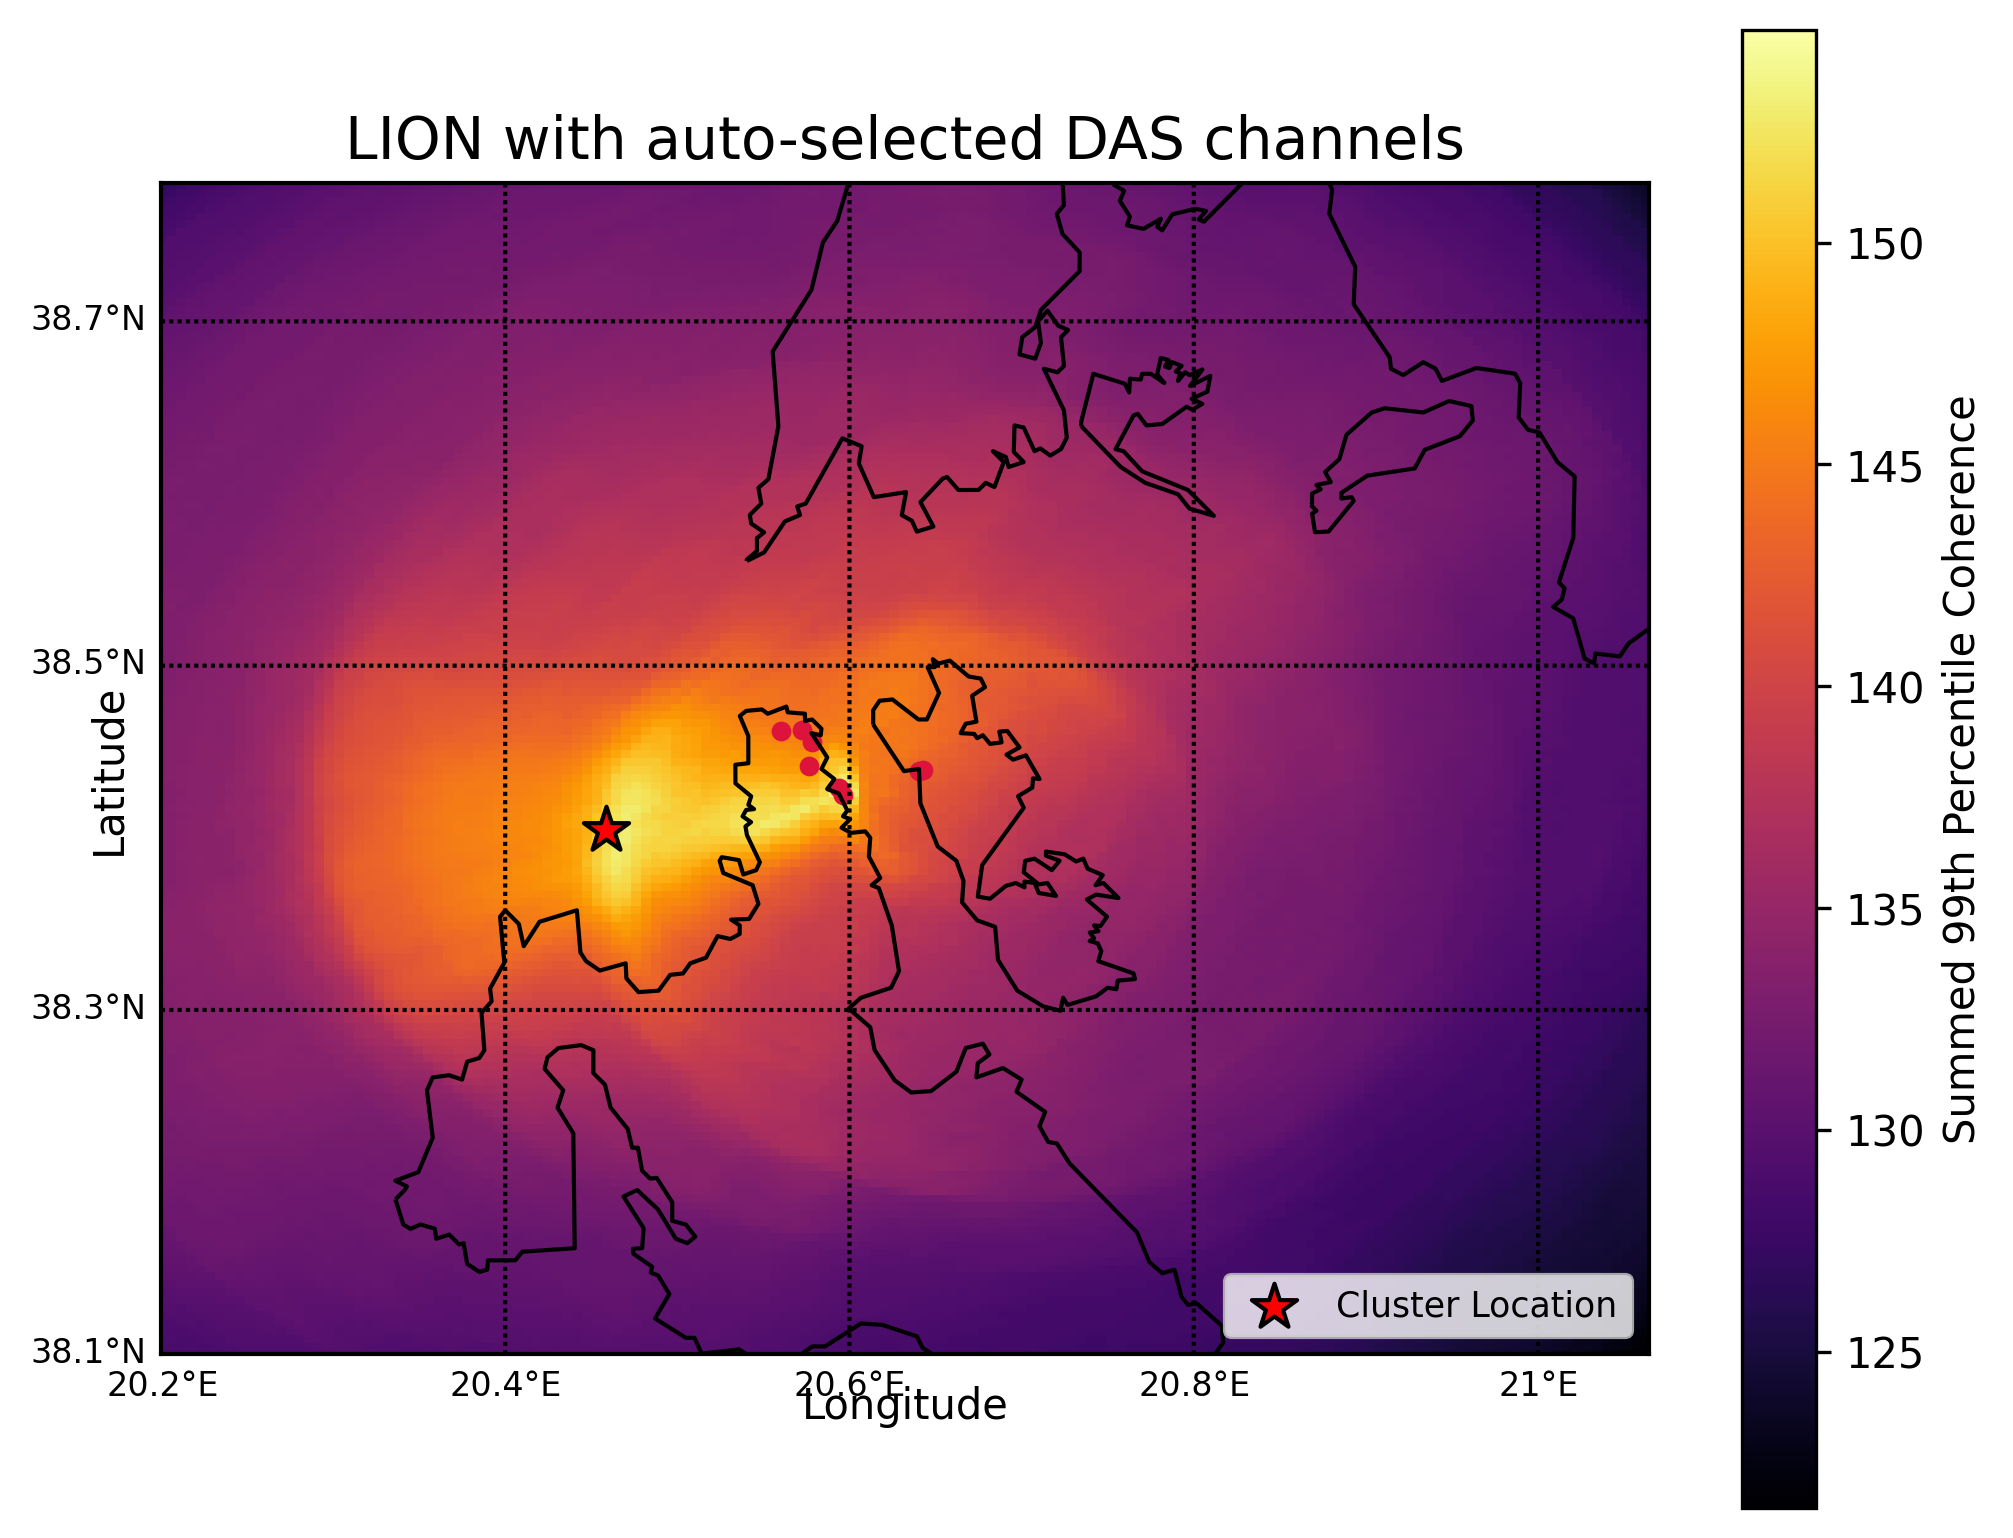

In [6]:
plot_fiber_only_map_with_percentile_sum(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.1, 38.78018018018018),
    lon_range=(20.2, 21.064340969963332),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_complete',
    title="LION with auto-selected DAS channels"
)
